# Examining Patterns in Wine Quality Using Physicochemical Markers

Bradford Spoerri 
  
DS 5010: Prgramming for Data Science
    
Northeastern University
    
Maryam Farahmand, Phd.
    
04/23/2026

*Author's note*

I selected this dataset since my partner and I have recently found much joy sampling new wines. This has partly been inspired by the Apple TV show "Drops of God" and also because I've recently acquired a small wine collection which formerly belonged to a relative. Lastly, my partner's family lives in Spain and we will be meeting them for a vacation at the end of this Semester in Portugal (where the wines in this combined dataset originate from). So, many factors came together and made this a dataset I was curious to explore.

## About the data (wine)

These datasets are made up samples taken from red and white vinho verde wines. Vinho Verde is not a grape variety, but instead signifies a regional origin of the wine in the Minho Province of nothern Portugal. These wines are typically known for their "acidity" and "freshness," however, aromas and notes can vary with grape variety. Most Vinho Verde wines are "young," meaning they are released within a few months and consumed not long after being bottled.  

## Reading and Interpreting the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# import UC Irvine wine data sets (note: dataset is semi-colon delimited)
red_wines = pd.read_csv('wine+quality/winequality-red.csv',  sep=';')
white_wines = pd.read_csv('wine+quality/winequality-white.csv',  sep=';')

In [3]:
# preliminary investigation
print(red_wines.info())
print(white_wines.info())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null 

## Field Descriptions

**fixed acidity**

   Acidity is fundamental to a wine's flavor profile. Fixed acids (tartaric, malic, citric, and succinic) are those mostly originating from the grapes used in wine production. Warm climate grapes tend to have lower acidity. Low acidity can make a wine taste flat, but also may contribute to a softness many prefer. Sometimes fixed acids are added or neutralized depending on desired characteristics.

   Type: Continuous

   Units: g/L (tartaric acid) --> grams/Liter

**volatile acidity**

   Steam distillable acids present in wine (primarily acetic acid but also lactic, formic, butyric, and propionic acids) as a biproduct of microbial metabolism, not the grapes used to produce the wine, and are indicative of a "spoilage" product such as vinegar. They are minimized by reducing oxygen exposure and adding sulfur dioxide to preserve complexity and depth of wine flavor. Volatile acids can result in off-putting aromas. They may also disrupt the fermentation process.

   Type: Continuous
   
   Units: g/L (acetic acid) --> grams/Liter

**citric acid**

   Citric acid is a "fixed acid" is often added to wines as a means of increasing acidity or complementing specific flavors. Cirtric acid can also improve a wines ferric stability (preventing excess iron which can result during formentation). The primary byproduct of citric acid is diacetyl which has a buttery odor in flavor. Too much citric acid can also increase the production of volatile acids which are generally not desired.

   Type: Continuous

   Units: g/L --> grams/Liter

**residual sugar**

   Naturally occurring sugar remaining in wine after the fermentation process. Wines are typically bucketed into "Bone Dry," "Dry," "Off-Dry," "Medium-Sweet," and "Sweet" categories (0-4 g/L, 5-11 g/L, 12-35 g/L, 35+ g/L respectively). During fermentation, yeast eats the sugar until the fermentation process is stopped. Thus, most sweet wines will have a lower alcohol content. 

   Type: Continuous

   Units: g/L --> grams/Liter

**chlorides**

   Chloride concentration in wine is predominantly influenced by a wine's *Terrior* (properties of geographical origin and type of grape). Flavor is strongly impacted by chloride ions and in too high concentrations can result in an undesirable salty taste.

   Type: Continuous

   Units: g/L (sodium chloride) --> grams/Liter
   
**free sulfur dioxide**

   Free (unbound) sulfur dioxide acts as an antioxidant, removing oxygen suspended in the wine. Reducing oxygen level slows down aging, reduces accumulation of volatile acids, and has an antimicrobial effect. Annecdotally, sulfites (sulfur dioxide) are attributed with causing headaches, however, these claims have not been corroborated by medical research.

   Type: Continuous

   Units: mg/L --> milligrams/Liter

**total sulfur dioxide**

  Sum of free and molecularly bound sulfur dioxide. Note that only free sulfur dioxide has preservative properties. The maximum allowable concentration is 350 mg/L in the USA and 150 mg/L for red wine and 200 mg/L for white in the EU.

  Type: Continuous

  Units: mg/L --> milligrams/Liter
  
**density**

  Wine density implies its mass per volume. Though density may be affected by disolved solids, it is primary influenced by alcohol content, whereby a wine's density should predictablly decrease as it's alcohol content increases. 

  Type: Continuous

  Units: g/mL --> grams/milliliter
  
**pH**

   Overall measure of the wine's acidity. White wines are generally more acidic than red wines. 3.8pH is generally considered the upper threshold, above which wine does not have sufficient acidity to prevent spoilage.

   Type: Continuous

   Units: pH --> 0-14 scale (acidic-basic)

**sulphates**

   Refers to potassium sulphate salts, unrelated to free sulfur dioxide, which is added to support sulfur dioxide levels during fermentation.

   Type: Continuous

   Units: g/L (potassium sulphate) --> grams/Liter

**alcohol**

   Alcohol results from the fermentation process. Winemakers control the duration of the fermentation process to target desired taste characteristics. Wine's taste is significantly influenced by alcohol with higher alcohol contents resulting in more "full-bodied" flavor, more pronounced "mouthfeel," and a longer-lasting finish on the palate.

   Type: Continuous

   Units: % alcohol/volume

**quality**

   Human rated score between 0 and 10.

   Type: Ordinal



In [4]:
# quick check to confirm there are no rows with a null value across all columns
null_check = lambda df: df.isna().any(axis=1).sum()
print(f"Red Wine dataset has {null_check(red_wines)} of {len(red_wines)} rows with a null value.")
print(f"White Wine dataset has {null_check(white_wines)} of {len(white_wines)} rows with a null value.")

Red Wine dataset has 0 of 1599 rows with a null value.
White Wine dataset has 0 of 4898 rows with a null value.


In [5]:
# add type ("red" or "white") as a field in each independent dataset prior to joining
red_wines['type'] = 'red'
white_wines['type'] = 'white'

# concatenate data sets together-same table structures for each set
combined = pd.concat([red_wines, white_wines])
combined = combined.sort_values(by='quality', ascending=False)

# save an original version
original_combined = combined.copy()

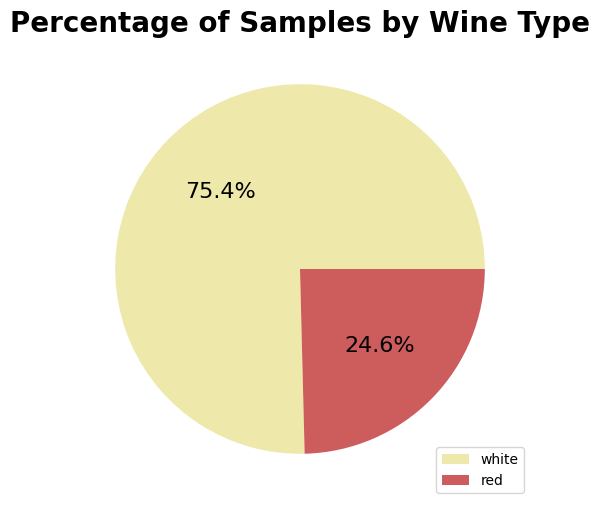

In [6]:
# calculate percentages of each type of wine
percentages = combined['type'].value_counts(normalize=True).round(3) * 100

# create pie chart
plt.figure(figsize=(6,6))
plt.pie(percentages, 
        autopct='%.1f%%',
        colors=['palegoldenrod', 'indianred'],
        textprops={'fontsize': 16})
plt.title('Percentage of Samples by Wine Type',
          fontweight='bold',
         fontsize=20,
         pad=0)
plt.legend(labels=percentages.index, loc='lower right')
plt.savefig('Images/type_compisition.png', dpi= 75)

## Initial Impressions

Combined, the two datasets contain **6,497 total samples**. Red wines make up about 1/4 of the total samples, with whites making up the remaining. These proportions are representative of the respective production volumes for each type of wine in the region. 

The dataset has **exceptional completeness** with no missing physicochemical marker entries or ratings for any of the samples.

*NOTE: I began working on the project before written requirements were provided (only initial guidance was that our dataset needed to come from UCIRVINE). There are fewer than 10,000 records. I tried to confirm an exception given significant progress I had already made but did not receive a response on my inquiry.*

## Question 1
#### *Function*

#### How are ratings distributed across each type of wine?

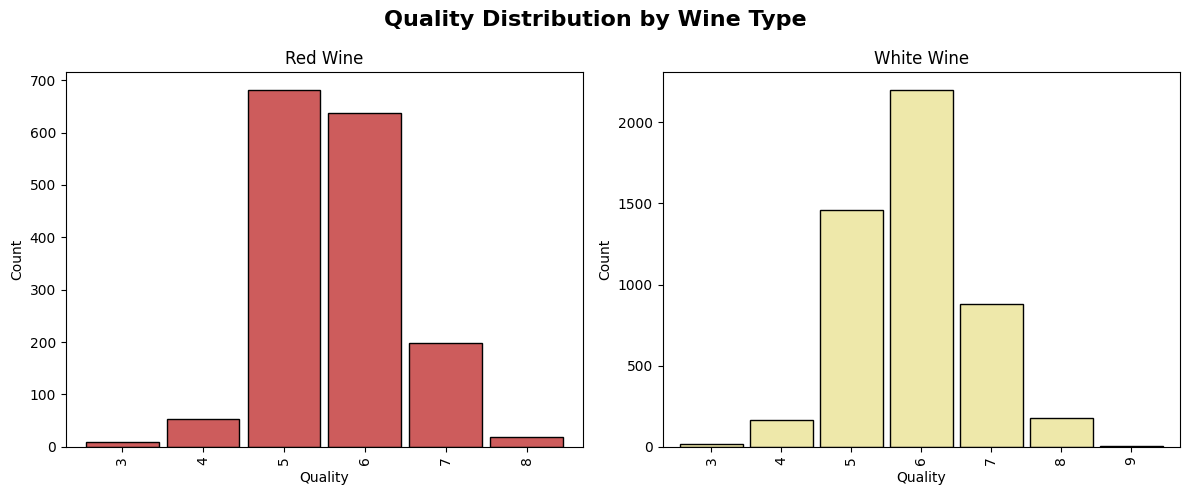

In [7]:
# initialize subplots to create side-by-side bar charts
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# iterate through each wine type and its corresponding axis
for ax, (wine_type, group) in zip(axes, combined.groupby('type')):
    # count occurrences of each quality score and sort by quality level
    counts = group['quality'].value_counts().sort_index()
    
    # plot bar chart with color based on wine type
    counts.plot(kind='bar',
                ax=ax,
                color='indianred' if wine_type == 'red' else 'palegoldenrod',
                edgecolor='black',
                width=0.9)
    ax.set_title(f'{wine_type.title()} Wine')
    ax.set_xlabel('Quality')
    ax.set_ylabel('Count')

# add title and adjust layout to prevent overlap
plt.suptitle('Quality Distribution by Wine Type', 
             fontweight='bold',
             fontsize=16)
plt.tight_layout()
plt.savefig('Images/quality_distributions.png', dpi= 125)

In [8]:
# despite quality being an ordinal scale, we can take some descriptive statistics
Q1 = lambda x: np.percentile(x,25)
Q3 = lambda x: np.percentile(x,75)
IQR = lambda x: np.percentile(x,75) - np.percentile(x,25)

# compile sample descriptive statistics
stat_summary = combined.groupby('type')['quality'].agg(['mean','std',
                                         Q1,'median',Q3,IQR])
# relabel columns to account for user-defined functions in agg
stat_summary.columns = ['Mean', 'Std', 'Q1', 'Median', 'Q3', 'IQR']

print(stat_summary.round(3))

        Mean    Std   Q1  Median   Q3  IQR
type                                      
red    5.636  0.808  5.0     6.0  6.0  1.0
white  5.878  0.886  5.0     6.0  6.0  1.0


#### **Question 1 findings:**

Both wine types exhibit **strong central tendency**. As such, most wines are clearly rated as mid-quality and fewer wines fall on the low or premium ends of the scale. Also, quality ratings for both wine types do not span the full potential range of 0-10. 

Both types show **slight left (negative) skew** indicating more spread toward lower quality ratings.

## Question 2
#### *Function*

#### What percentage of each type of wine is very high quality (>7)?

In [9]:
# calculate percentage of premium wines (quality >= 7) for each type
# lambda aggregates by counting scores >= 7, dividing by total, and formatting as percentage
premium_pct = combined.groupby('type')['quality'].agg(
    lambda x: f'{((x >= 7).sum() / len(x) * 100).round(2)}%'
)
print('PERCENT PREMIUM (>=7 Rating)')
print(premium_pct)

PERCENT PREMIUM (>=7 Rating)
type
red      13.57%
white    21.64%
Name: quality, dtype: str


#### **Question 2 findings:**

About one in five white wines is expected to be a premium wine. Additionally, **white wines are almost twice as likely to be premium**, meaning rated greater than 7, than red wines. 

There is a far greater quantity of premium white wines in the population than there is for premium red wines.

## Question 3
#### *Function*

#### How does sweetness vary between the different types of wine?

In [10]:
def sweetness_labels(df, col='residual sugar'):
    '''
    sweetness_labels function transforms residual sugar content into the conventionally
    descriptive categories used in marketing wine and describing its flavor profile.

    Parameters:
        df (DataFrame) - dataframe onto which sweetness column will be appended
        col (string) - name of existing column which should be used in transformation
    '''
    # designate sweetness bins
    bins = [-0.1, 4, 12, 35, 120, float('inf')]
    labels = ['bone dry', 'dry', 'off-dry', 'medium-sweet', 'sweet']
    # use cut function to create a series of binned values; add series to df
    df['sweetness'] = pd.cut(df[col],
                             bins=bins,
                             labels=labels)
    return df

# updated combined dataframe to include sweetness field
combined = sweetness_labels(combined)

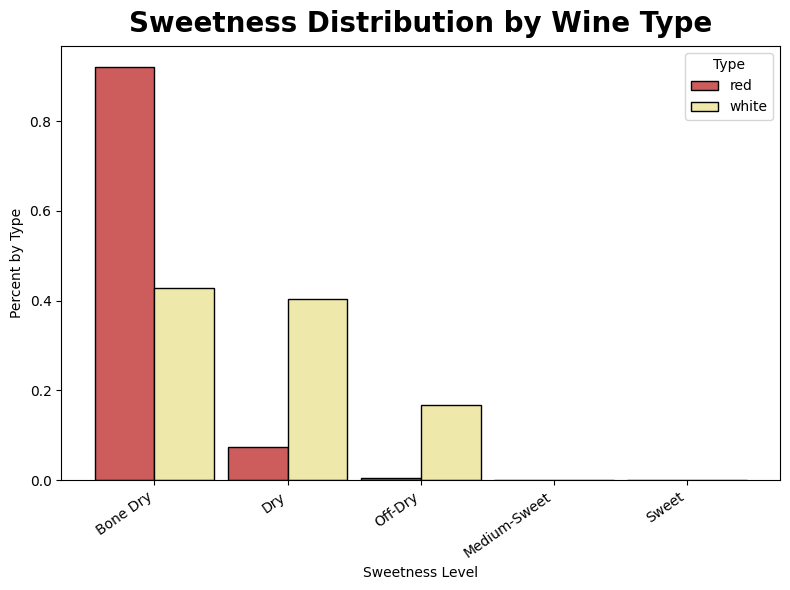

In [23]:
# get normalized value counts (pct) for each sweetness bucket by type
# unstack moves wine type from row index to columns for grouped bar chart
sweetness_pct = (combined.groupby('type')['sweetness']
                 .value_counts(normalize=True)
                 .unstack(level=0)
                 .sort_index())

# reformat sweetness labels for display with map
sweetness_pct.index = sweetness_pct.index.map(lambda x: x.title())

# plot grouped bar chart with styling
sweetness_pct.plot(kind='bar', 
                   figsize=(8, 6),
                   color=['indianred', 'palegoldenrod'],
                   edgecolor='black',
                   width=0.9)
plt.title('Sweetness Distribution by Wine Type', 
          fontsize=20,
          fontweight='bold',
          pad=10)
plt.xlabel('Sweetness Level')
plt.ylabel('Percent by Type')
plt.legend(title='Type')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('Images/sweetness_distribution.png', dpi= 125)

#### **Question 3 findings:**

Roughly 90% of red wines classify as "Bone Dry" meaning they have less than 4 grams of residual sugar. So, sugar content is not likely to be a significant factor in differentiating red wines. White wines on the other hand fall more evenly across the first three sweetness categories. Thus, there is a greater likelihood, though no guarantee, that sweetness impacts quality of white wine. However, more analysis would be required to discern if any such relationship actually exists. 

Generally, **sugar content could be a useful feature for distinguishing between red and white wines** (i.e. classification).

## Question 4
#### *Visualization*

#### How does overall acidity (pH) vary by type of wine?

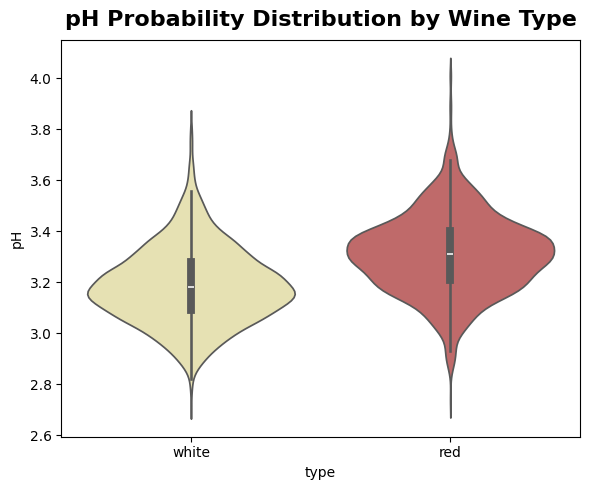

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
# create violin with seaborn
sns.violinplot(data=combined, x='type', y='pH', 
               hue='type', palette=default_colors, 
               legend=False, ax=ax)
ax.set_title('pH Probability Distribution by Wine Type', 
             fontweight='bold',
             fontsize=16,
             pad=10)
plt.tight_layout()
plt.savefig('Images/pH_violin.png')

#### **Question 4 findings:**

Though red and white wines share somewhat similar looking pH distributions, there is a distinct difference in acidity levels between the two types of wine. **White wine clearly tends to be more acidic than red wine.** Neither wine type is likely to exceed a 3.8pH or fall below 2.9pH.

## Question 5
#### *Numpy/Pandas*

#### Does overall acidity (pH) impact perceived quality similarly for both red and white wines?

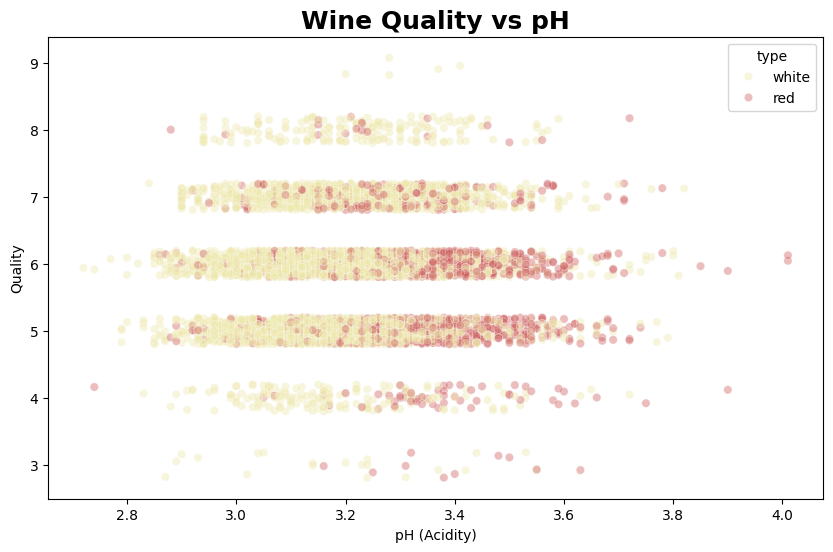

In [13]:
plt.figure(figsize=(10, 6))

# add random jitter to quality scores to reduce overplotting
# jitter spreads out points that share the same integer quality value
jittered_quality = combined['quality'] + np.random.uniform(-0.2, 0.2, len(combined))

# create scatter plot with color by wine type and transparency for density visibility
sns.scatterplot(x=combined['pH'], y=jittered_quality, hue=combined['type'], 
                palette={'red': 'indianred', 'white': 'palegoldenrod'}, alpha=0.4)

plt.xlabel('pH (Acidity)')
plt.ylabel('Quality')
plt.title('Wine Quality vs pH',
          fontsize=18,
          fontweight='bold')
plt.savefig('Images/quality_vs_pH_scat', dpi= 125)   

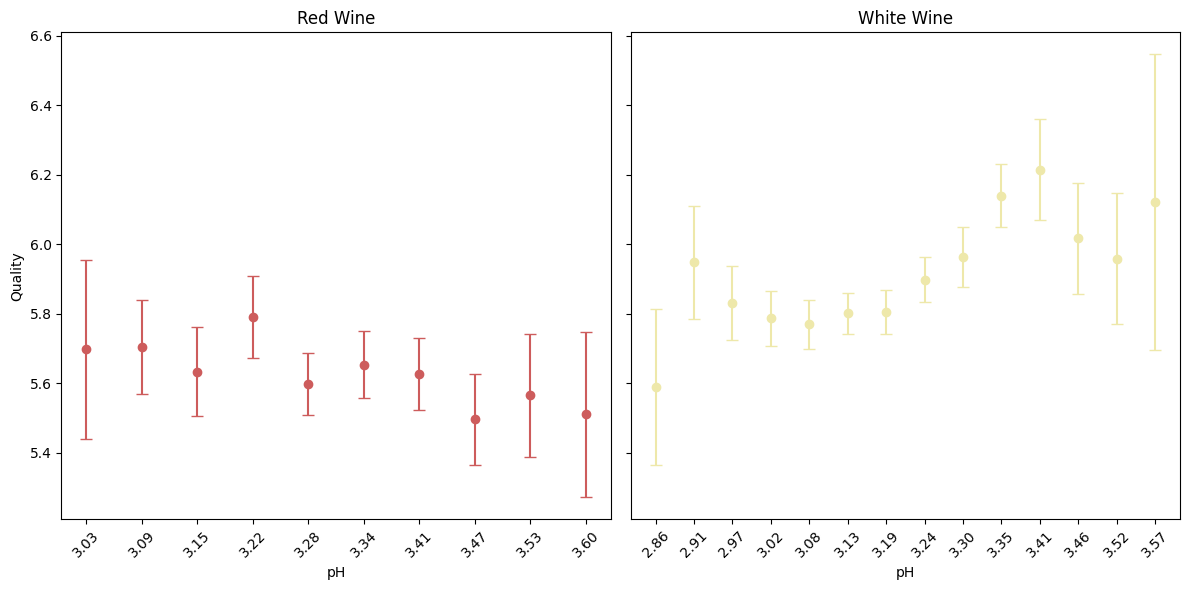

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# plot error bars for mean quality across pH bins for each wine type
for ax, (wine_type, type_group) in zip(axes, combined.groupby('type')):
    # bin pH values into 20 intervals
    pH_bin = pd.cut(type_group['pH'], bins=20)
    
    # calculate mean, std, and count of quality for each pH bin
    quality_stats = type_group.groupby(pH_bin)['quality'].agg(['mean', 'std', 'count'])
    
    # filter out bins with too few samples for reliable statistics
    quality_stats = quality_stats[quality_stats['count'] >= 30]
    
    # calculate standard error for confidence intervals
    quality_stats['se'] = quality_stats['std'] / np.sqrt(quality_stats['count'])
    
    # plot mean quality with standard error bars
    ax.errorbar(range(len(quality_stats)), 
                quality_stats['mean'], 
                yerr=1.96 * quality_stats['se'],
                fmt='o', 
                capsize=4, 
                color=default_colors[wine_type])
    
    # label x-axis with midpoint of each pH bin
    ax.set_xticks(range(len(quality_stats)))
    ax.set_xticklabels([f'{i.mid:.2f}' for i in quality_stats.index], rotation=45)
    ax.set_xlabel('pH')
    ax.set_title(f'{wine_type.title()} Wine')

axes[0].set_ylabel('Quality')
plt.tight_layout()
plt.savefig('Images/quality_vs_pH.png', dpi= 125)   

#### **Question 5 findings:**

Acidity appears to impact perceived quality for red and white wines in different ways. For **reds, acid level appears to have a slight inverse correlation with quality** such that lower pH (more acidity) is more favorable on average. Contrastingly, rising PH (reducing acidity) in white wines appears to be more positively correlated with quality. However, **average ratings for white wines peak and begin to fall once pH exceeds 3.4**. This may indicate the acidity level for a "well-balanced" white wine.

## Question 6
#### *Numpy/Pandas*

#### How does the ratio of fixed to volatile acidity ("acidity ratio") differ by type of wine?

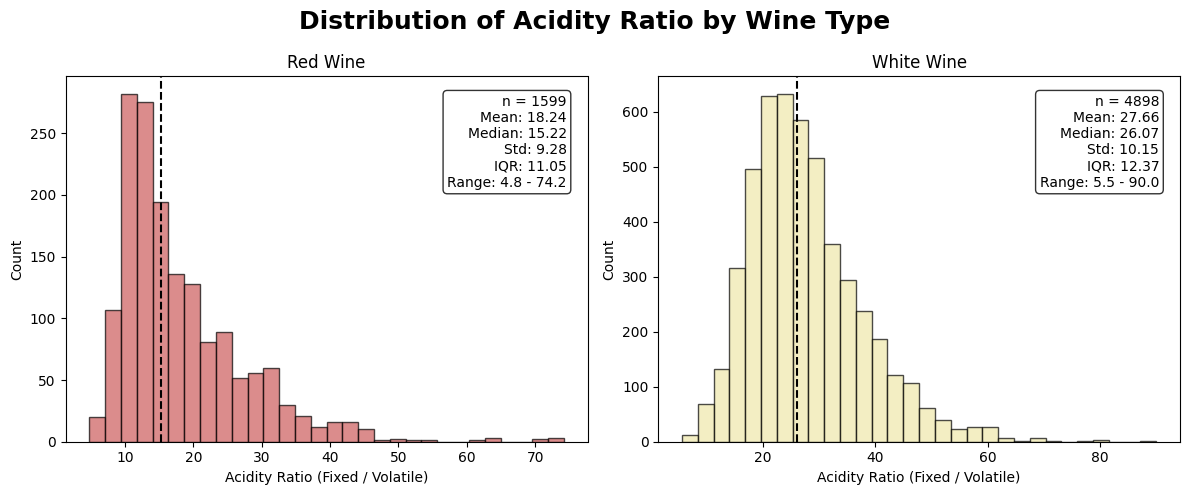

In [15]:
# calculate field for acidity ratio (fixed / volatile)
acidity_ratio = combined['fixed acidity'] / combined['volatile acidity']

# insert new column after volatile acidity
combined.insert(combined.columns.get_loc('volatile acidity') + 1, 'acidity ratio', acidity_ratio)

# create side-by-side histograms
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# plot acidity ratio distribution for each wine type
for ax, (wine_type, group) in zip(axes, combined.groupby('type')):
    data = group['acidity ratio']
    
    ax.hist(data, bins=30, 
            color=default_colors[wine_type],
            edgecolor='black', 
            alpha=0.7)
    ax.set_title(f'{wine_type.title()} Wine')
    ax.set_xlabel('Acidity Ratio (Fixed / Volatile)')
    ax.set_ylabel('Count')
    
    # add vertical line at median
    ax.axvline(data.median(), color='black', linestyle='--')
    
    # build summary statistics text box
    legend_text = (f'n = {len(data)}\n'
                   f'Mean: {data.mean():.2f}\n'
                   f'Median: {data.median():.2f}\n'
                   f'Std: {data.std():.2f}\n'
                   f'IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}\n'
                   f'Range: {data.min():.1f} - {data.max():.1f}')
    
    # place text box in upper right corner of each subplot
    ax.text(0.96, 0.95, legend_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
plt.suptitle('Distribution of Acidity Ratio by Wine Type', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('Images/acidity_ratio_distributions.png', dpi= 125)   

#### **Question 6 findings:**

**Red wines have a much lower ratio** of fixed to volatile acidity than whites. This seems to align with the fact that white wines are more acidic overall (with primary contributor to overall acidity being the fixed component). Upon further research, these results are corroborated by the fact that white wine grapes are typically harvested earlier than red wine grapes to preserve more of their acidity (which supports crisp/zesty flavor). 

The acidity ratio for red wines varies less for red wines than it does for whites. Similarly **red wines are less normally distributed with more apparent right tail skew** than white wines. White wines also have a right tail skew but it is less pronounced.

## Question 7
#### *Visualization*

#### Does chemical marker dispersion vary between wine types?

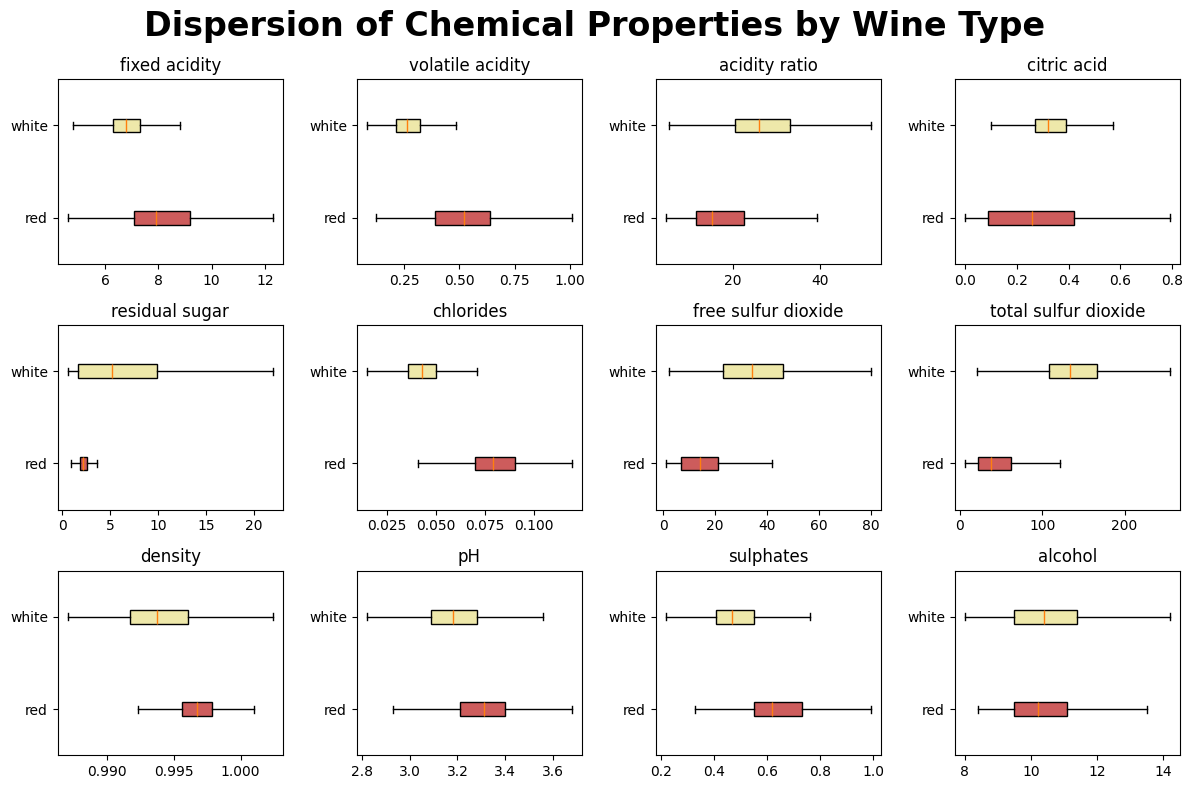

In [16]:
# select all numeric columns except the target variable
numerical_markers = combined.select_dtypes(include='number').columns.drop('quality')

# create 3x4 grid of subplots for the 12 features
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8))

for ax, column in zip(axes.flat, numerical_markers):
    # split data by wine type for side-by-side comparison
    data = [combined.loc[combined['type'] == t, column] for t in ['red', 'white']]
    
    # horizontal boxplots without outliers
    bp = ax.boxplot(data, 
                    tick_labels=['red', 'white'], 
                    patch_artist=True,
                    vert=False,
                    showfliers=False)
    
    # apply established colors to each box
    for patch, color in zip(bp['boxes'], ['indianred', 'palegoldenrod']):
        patch.set_facecolor(color)
    
    ax.set_title(column)
    
    # density values are very close together (~0.99x), so show more decimal places
    if column == 'density':
        ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

fig.suptitle('Dispersion of Chemical Properties by Wine Type', 
             fontsize=24, 
             fontweight='bold')

# increase vertical spacing between rows to prevent title overlap
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig('Images/marker_dispersions.png', dpi= 100)

#### **Question 7 findings:**

**Largest Separation (between types)**

Total & Free Sulfur Dioxide - White wines have dramatically higher levels vs reds (although they also have greater variance).

Residual Sugar - White wines show much higher median and greater spread vs red wines (corroborating prior sweetness analysis), which are tightly clustered.

Volatile Acidity -  Runs higher in reds than whites, which could be due to the red wines having a higher pH. Lower acidity means more microbes to contribute to volatile acidity. Intuitively, I would have guessed (incorrectly) that red wines had greater sulfur dioxide content to help mitigate volatile acidity (with less fixed acidity from the grapes).

**Moderate Separation**

Chlorides - Red wines have higher salt content with more outliers.

Fixed acidity & pH - Whites are discernibly more acidic (lower pH). Unclear as to why this might be since they show significantly lower fixed and volatile acid measurements. Could suggest that these features are not redundant. Perhaps the counter-intuitive behavior can be attributed to different acid compositions between wine types since fixed here only reflects tartic acid. pH could also be influenced by other compounds or reactions.

Density - Red wines cluster tighter around 0.997; whites have wider spread (likely driven by residual sugar variation).

**Minimal Separation**

Alcohol - Nearly identical distributions. Not useful for classification.

Sulphates - Slight red wine edge but substantial overlap.

Citric acid - Similar central tendency, though reds may have higher variance to right of mean.

## Question 8
#### *Pandas/Numpy*

#### Do median values for markers differ between extremes in quality?

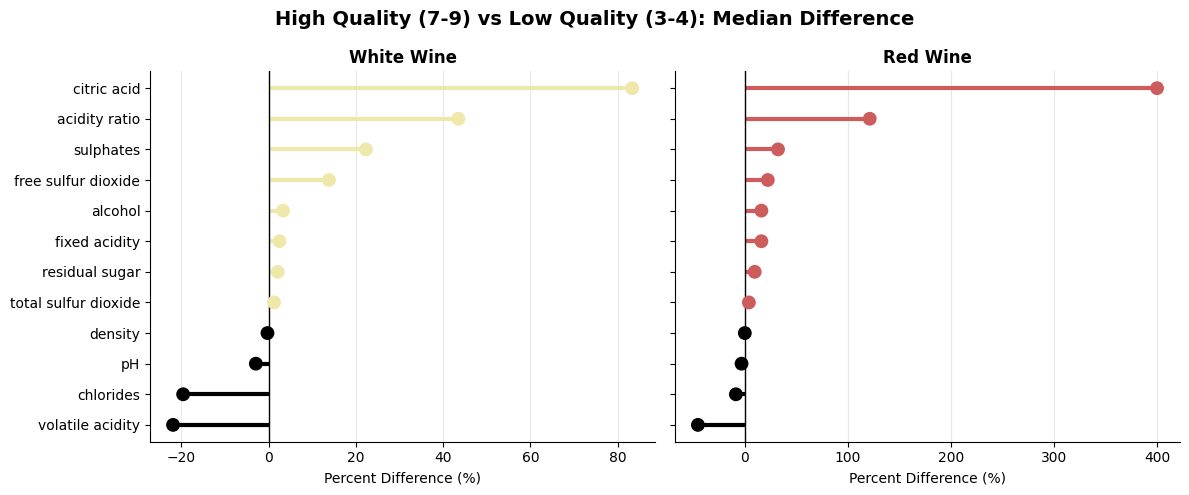

In [17]:
# keep rerunning numerical_markers to ensure any new derived features get included
numerical_markers = combined.select_dtypes(include='number').columns.drop('quality')

# side-by-side comparison of quality drivers for each wine type
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, wine_type in zip(axes, combined['type'].unique()):
    data = combined[combined['type'] == wine_type]
    
    # compute median feature values for quality extremes
    # low quality (3-4) vs high quality (8-9) to maximize contrast
    low_med = data[data['quality'].isin([3, 4])][numerical_markers].median()
    high_med = data[data['quality'].isin([7, 8, 9])][numerical_markers].median()
    
    # percent change: positive = higher in premium wines, negative = lower in premium wines
    pct_diff = ((high_med - low_med) / low_med) * 100
    results = pct_diff.sort_values().to_frame(name='pct_diff')
    

    colors = [default_colors[wine_type] if x > 0 else 'black' for x in results['pct_diff']]
    y_pos = range(len(results))
    
    # lollipop chart: line (stick) + scatter (head)
    ax.hlines(y=y_pos, xmin=0, xmax=results['pct_diff'], color=colors, linewidth=3)
    ax.scatter(results['pct_diff'], y_pos, color=colors, s=80, zorder=3)
    
    # zero baseline for visual reference and axis labels
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(results.index)
    ax.set_xlabel('Percent Difference (%)')
    ax.set_title(f'{wine_type.title()} Wine', fontweight='bold', fontsize=12)
    
    # remove spines for cleaner styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('High Quality (7-9) vs Low Quality (3-4): Median Difference', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('Images/medians_across_extreme_qualities.png', dpi= 150)   

#### **Question 8 findings:**

For both wine types, citic acid content varies dramatically between quality extremes. In both cases, **high citic acid content is far more prevelent in high quality wines** than low quality wines. For reds, the difference in median values is an astonishing 400+%. Considering most wines samples fall into the central quality ratings. This insight **may suggest that citric acid could be a helpful feature, if not for predicting a precise quality score (due to high variance shown by coefficient of variation), then for reliably categorizing outliers (bad and good).**

In addition to citric acid, **Acidity Ratio shows signicant disparity in median values** between low and high quality wines, especially for whites. This could suggest that **Acidity Ratio may be a more relevant feature for detecting outlier quality than the standard dataset markers** (though volatile acidity also did clearly deviate above).

## Question 9
#### *Pandas/NumPy*

#### Which markers have the greatest variation by wine type?

In [18]:
# keep rerunning numerical_markers to ensure any new derived features get included
numerical_markers = combined.select_dtypes(include='number').columns.drop('quality')

# grab coefficient of variation for each marker by type as a reference
cv_by_type = combined.groupby('type')[numerical_markers].agg(lambda x: round(x.std() / x.mean() * 100, 2))
cv_by_type = cv_by_type.T
cv_by_type.columns = [f'{col}' for col in cv_by_type.columns]
cv_by_type['difference'] = abs(cv_by_type['red'] - cv_by_type['white'])

print("Coefficient of Variation by Wine Type")
print("=" * 50)
print(cv_by_type.sort_values(by='difference', ascending=False))
print(f"\nRed Wine - most variable marker:   {cv_by_type['red'].idxmax()} ({cv_by_type['red'].max():.3f})")
print(f"White Wine - most variable marker: {cv_by_type['white'].idxmax()} ({cv_by_type['white'].max():.3f})")
print(f"\nGreatest CV diff between types: {cv_by_type['difference'].abs().idxmax()}")

Coefficient of Variation by Wine Type
                        red  white  difference
total sulfur dioxide  70.79  30.72       40.07
citric acid           71.89  36.21       35.68
residual sugar        55.54  79.36       23.82
free sulfur dioxide   65.89  48.17       17.72
acidity ratio         50.86  36.68       14.18
fixed acidity         20.93  12.31        8.62
chlorides             53.81  47.73        6.08
sulphates             25.76  23.30        2.46
volatile acidity      33.92  36.23        2.31
alcohol               10.22  11.70        1.48
density                0.19   0.30        0.11
pH                     4.66   4.74        0.08

Red Wine - most variable marker:   citric acid (71.890)
White Wine - most variable marker: residual sugar (79.360)

Greatest CV diff between types: total sulfur dioxide


#### **Question 9 findings:**

*See print summary above*

One way of potentially interpreting these results is that **markers with high CVs may be more subject to creative variability** in the wine making process. For example, makers of red wine may have more liberty to add (or not add) vastly different amounts of citric acid while still producing a viable product. Conversely, **low CV markers might be more useful for predicting quality outliers**, since they might indicate markers with greater sensitivity to deviation (e.g. alcohol, denisty, pH). 

This is just a hypothesis since we previously have shown counter-examples such as that median citric acid levels were signficantly different between extremes in quality.

## Question 10
#### *Visualization*

#### What are the correlations between physicochemical markers and overall quality?

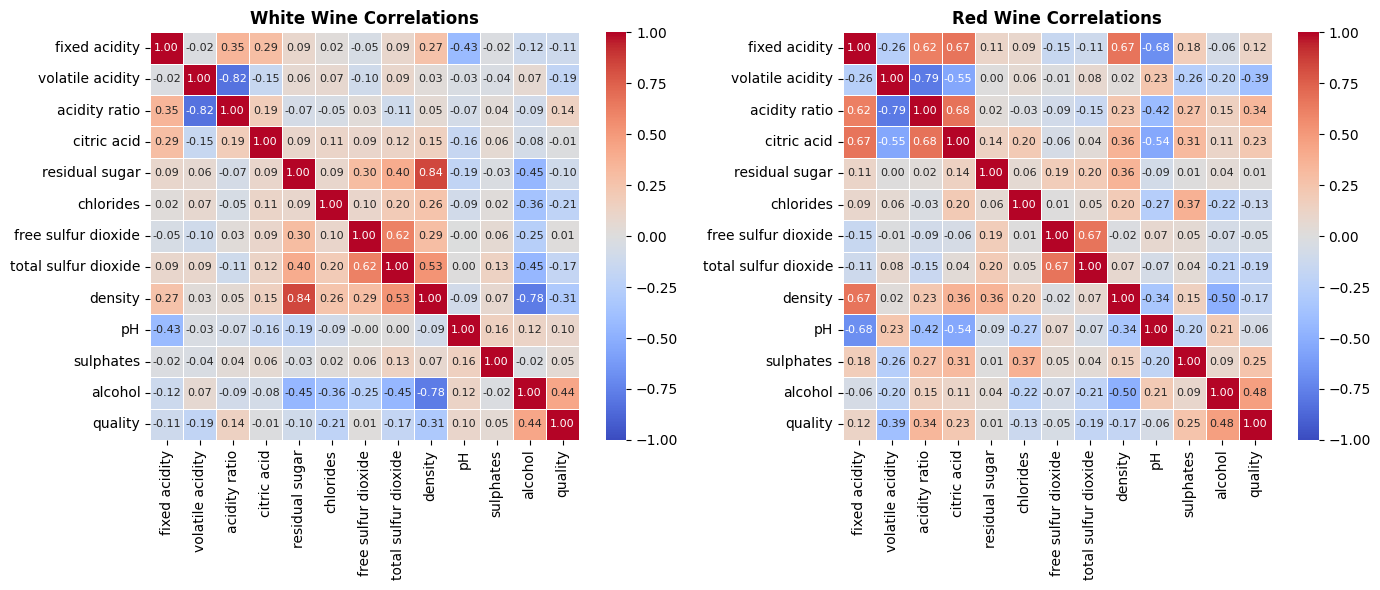

In [19]:
# keep quality, thus numerical columns convention
numerical_columns = [col for col in combined.select_dtypes(include=['number']).columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# correlation heatmaps for red and white wines separately
for ax, wine_type in zip(axes, combined['type'].unique()):
    subset = combined[combined['type'] == wine_type]
    
    # correlation matrix for all numeric features
    correlation_matrix = subset[numerical_columns].corr()
    
    # heatmap with diverging colormap centered at zero
    # red = positive correlation, blue = negative correlation
    sns.heatmap(correlation_matrix, 
                annot=True,          
                fmt='.2f',           
                cmap='coolwarm',     
                center=0,            # white for zero correlation
                linewidths=0.5,      
                vmin=-1, 
                vmax=1,              # fix scale to full correlation range
                annot_kws={'size': 8},
                ax=ax)
    ax.set_title(f"{wine_type.title()} Wine Correlations", 
                 fontweight='bold')

plt.tight_layout()
plt.savefig('Images/correlation_heatmaps.png', dpi= 125)   

In [20]:
# compute correlation matrices grouped by wine type
correlation_coefficients = combined.groupby(['type'])[numerical_columns].corr()

for wine_type in combined['type'].unique():
    print(f'{wine_type.title()} Wine Correlations:')
    print('=' * 75)
    
    type_corrs = correlation_coefficients.loc[wine_type]
    
    # correlations with quality, sorted strongest to weakest
    quality_corrs = type_corrs['quality'].drop('quality').sort_values(ascending=False)
    
    for marker in quality_corrs.index:
        quality = quality_corrs[marker]
        
        # find strongest correlation for this marker excluding itself and quality
        # use abs() to find strongest regardless of direction
        marker_corrs = type_corrs.loc[marker].drop(['quality', marker]).abs()
        top_pairing = marker_corrs.idxmax()
        pairing_corr = type_corrs.loc[marker, top_pairing]
        
        print(f'{marker:25} quality: {quality:+.2f}   top pair: {top_pairing} ({pairing_corr:+.2f})')
    
    print()

White Wine Correlations:
alcohol                   quality: +0.44   top pair: density (-0.78)
acidity ratio             quality: +0.14   top pair: volatile acidity (-0.82)
pH                        quality: +0.10   top pair: fixed acidity (-0.43)
sulphates                 quality: +0.05   top pair: pH (+0.16)
free sulfur dioxide       quality: +0.01   top pair: total sulfur dioxide (+0.62)
citric acid               quality: -0.01   top pair: fixed acidity (+0.29)
residual sugar            quality: -0.10   top pair: density (+0.84)
fixed acidity             quality: -0.11   top pair: pH (-0.43)
total sulfur dioxide      quality: -0.17   top pair: free sulfur dioxide (+0.62)
volatile acidity          quality: -0.19   top pair: acidity ratio (-0.82)
chlorides                 quality: -0.21   top pair: alcohol (-0.36)
density                   quality: -0.31   top pair: residual sugar (+0.84)

Red Wine Correlations:
alcohol                   quality: +0.48   top pair: density (-0.50)
acidi

#### **Question 10 findings:**

Quality Correlations:

*White Wine*

**Alcohol content and acidity ratio are most POSITIVELY correlated with quality**. Contrastingly, density, chlorides, volatile + fixed acidities, and total sulfur are most NEGATIVELY correlated. Since **alcohol and density have a strong inverse correlation, these may be redundant/interfering features**, especially given similarly strong pair-wise correlation between density and residual sugar. 

It was **surprising to see that fixed acidity was negatively correlated with quality for white wines** given the previously observed positive difference in this marker between low and high quality wines. That said, we have previously seen how white wine quality improves as pH increases up to a peak of 3.4.


*Red Wine*

**Key difference from white wine is that sulphates and citric acid have a relatively stronger correlations with quality.**


General Note: One thing correlation does not show is which features might be weakly relevant in predicting quality alone, but which become more relevant or significant when depending the presence or quantity of other features (i.e. non-linear relationships).

## Question 11
#### *Pandas/Numpy*

#### How does alcohol content impact quality for each wine type?

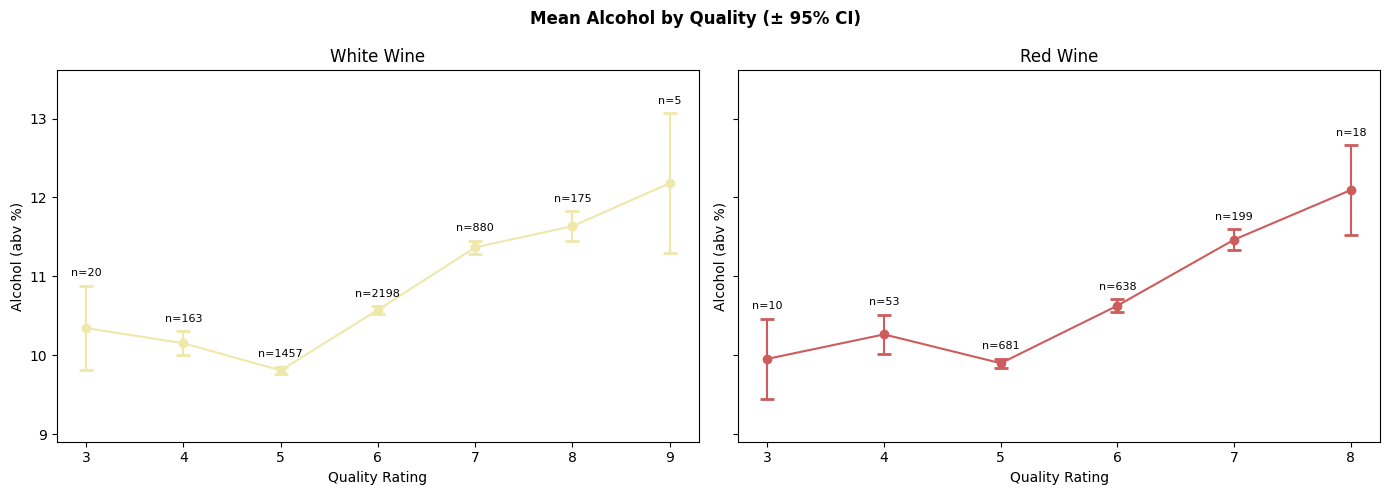

In [21]:
# aggregate alcohol statistics by wine type and quality level
alc_stats = combined.groupby(['type', 'quality'])['alcohol'].agg(['mean', 'std', 'count'])

# 95% confidence interval margin of error: 1.96 * standard error
alc_stats['moe'] = 1.96 * alc_stats['std'] / np.sqrt(alc_stats['count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, wine_type in zip(axes, combined['type'].unique()):
    alc_stats_by_type = alc_stats.loc[wine_type]
    
    # error bars show 95% CI around mean alcohol for each quality level
    ax.errorbar(alc_stats_by_type.index, 
                alc_stats_by_type['mean'], 
                yerr=alc_stats_by_type['moe'],
                marker='o', 
                capsize=5, 
                capthick=2, 
                color='indianred' if wine_type == 'red' else 'palegoldenrod')
    
    # annotate sample size above each error bar
    for quality in alc_stats_by_type.index:
        mean = alc_stats_by_type.loc[quality, 'mean']
        moe = alc_stats_by_type.loc[quality, 'moe']
        count = alc_stats_by_type.loc[quality, 'count']
        ax.annotate(f'n={int(count)}', (quality, mean + moe + 0.12), 
                    ha='center', fontsize=8)
        
    ax.margins(y=0.15)
    ax.set_xlabel('Quality Rating')
    ax.set_ylabel('Alcohol (abv %)')
    ax.set_title(f'{wine_type.title()} Wine')

fig.suptitle('Mean Alcohol by Quality (± 95% CI)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('Images/quality_vs_abv.png')   

#### **Question 11 findings:**

**Strong positive association between alcohol and quality** for both wine types. Higher-rated wines consistently have higher alcohol content, with mean ABV climbing from ~10% at quality 3-4 to ~12% at quality 8-9.

## Question 12
#### *Pandas/Numpy*

#### How do alcohol content and wine density relate to one another?

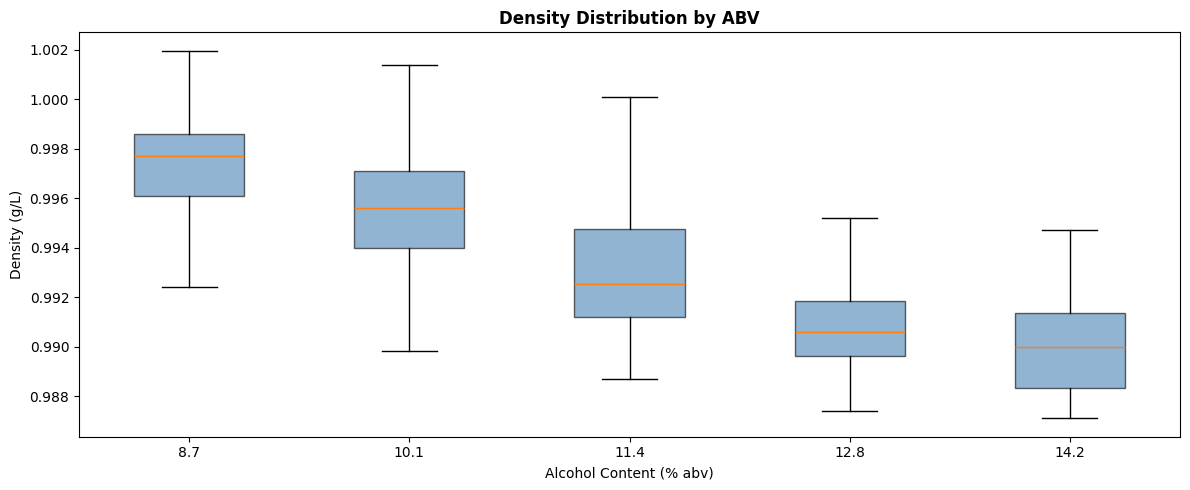

In [22]:
# bin alcohol into 5 equal-width intervals for grouped analysis
alcohol_bins = pd.cut(combined['alcohol'], bins=5)

# group density values by alcohol bin
binned_data = combined.groupby(alcohol_bins)['density']
# iterating over groupby object yields (bin_interval, corresponding df) pairs
data = [group.values for name, group in binned_data]
# use alcohol bin midpoint for tick labels
labels = [f'{name.mid:.1f}' for name, group in binned_data]

fig, ax = plt.subplots(figsize=(12, 5))

# create box plot
bp = ax.boxplot(data, 
                tick_labels=labels, 
                patch_artist=True, 
                showfliers=False)

# style boxes
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)

ax.set_xlabel('Alcohol Content (% abv)')
ax.set_ylabel('Density (g/L)')
ax.set_title('Density Distribution by ABV',
            fontweight="bold")
plt.tight_layout()
plt.savefig('Images/abv_vs_density.png', dpi= 125)   

#### **Question 12 findings:**

**Strong negative relationship** between alcohol content and density. As ABV increases from ~8.7% to ~14.2%, median density drops from ~0.998 to ~0.990 g/L.

This demonstrates the general chemical expectation given that alcohol (developed during fermentation) is less dense than water.

## Question 13
#### *Visualization*

#### Is Free Sulfur a good feature for wine type classification?

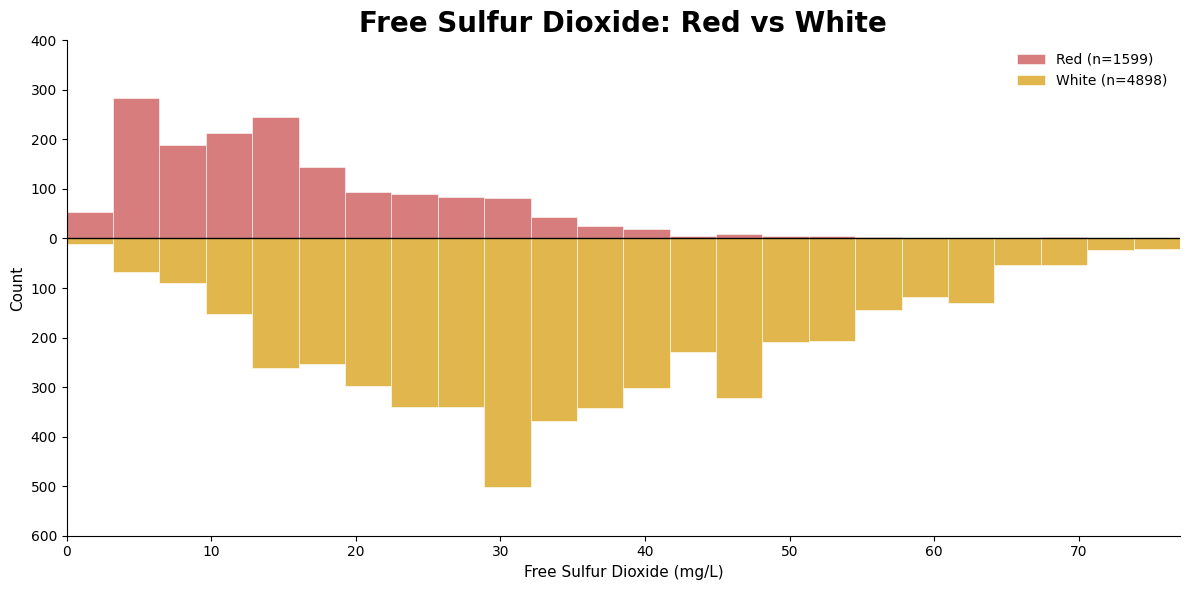

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

red_data = combined.loc[combined['type'] == 'red', 'free sulfur dioxide']
white_data = combined.loc[combined['type'] == 'white', 'free sulfur dioxide']

# trim extreme outliers by capping at 99th percentile for cleaner visualization
upper_bound = combined['free sulfur dioxide'].quantile(0.99)
bins = np.linspace(0, upper_bound, 25)

# red wine histogram: upward bars
ax.hist(red_data[red_data <= upper_bound], bins=bins, color='indianred', alpha=0.8, 
        edgecolor='white', linewidth=0.5, label=f'Red (n={len(red_data)})')

# white wine histogram: negative weights flip bars for back-to-back comparison
ax.hist(white_data[white_data <= upper_bound], bins=bins, color='goldenrod', alpha=0.8, 
        edgecolor='white', linewidth=0.5, 
        weights= -1 * np.ones(len(white_data[white_data <= upper_bound])),
        label=f'White (n={len(white_data)})')

# convert y-axis labels to absolute values since negative is artificial
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([int(abs(y)) for y in ax.get_yticks()])

# center dividing line between the two distributions
ax.axhline(0, color='black', linewidth=1)

ax.set_xlim(0, upper_bound)
ax.set_xlabel('Free Sulfur Dioxide (mg/L)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Free Sulfur Dioxide: Red vs White', fontweight='bold', fontsize=20)
ax.legend(loc='upper right', frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Images/free_sulfur_dual_distribution.png', dpi= 125)   

#### **Question 13 findings:**

There is clear separation (minimal overlap) in the distribution of SO₂ by wine type. Red wines cluster at lower levels, while white wines are spread more widely across almost double the range. Very few red wines exceed 30 mg/L, which appears as the median for whites. **This marker has strong classification potential** if trying to categorize by type.

This visualization could provide evidence that white wines lack natural antioxidants and that winemakers add more SO₂ to prevent spoilage and desired flavors. Similarly, this diagram **helps to dispell the urban-legend that sulfites cause headaches.** This is because red wines are often blamed for triggering the headaches rather than whites, but clearly, they have lower free sulfur quantities.

## Question 14
#### *Numpy/Pandas*

#### Does Free Sulfur (sulfites) content have any clear impact on quality rating?

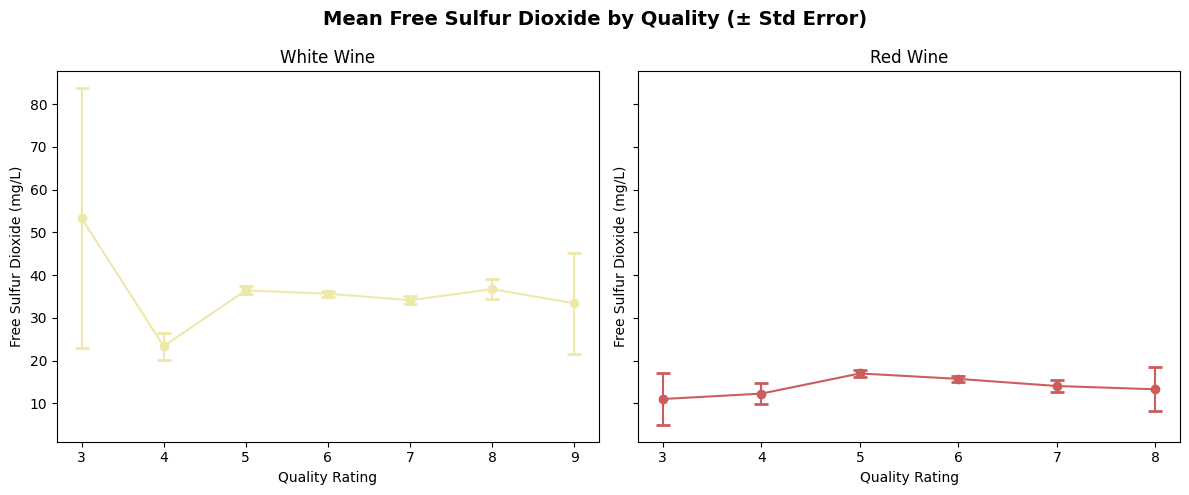

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# compare free SO2 levels across quality ratings for each wine type
for ax, wine_type in zip(axes, combined["type"].unique()):
    data = combined.loc[combined["type"] == wine_type]
    
    # compute mean, 95% CI margin of error for error bars
    sulfur_stats = data.groupby("quality")["free sulfur dioxide"].agg(
        mean='mean', 
        moe=lambda x: 1.96 * (x.std() / (len(x) ** 0.5))
    )
    
    # error bars show 1 standard error around mean
    ax.errorbar(sulfur_stats.index, sulfur_stats['mean'], yerr=sulfur_stats['moe'], 
                marker='o', capsize=5, capthick=2,
                color=default_colors[wine_type])
    ax.set_title(f'{wine_type.title()} Wine')
    ax.set_xlabel('Quality Rating')
    ax.set_ylabel('Free Sulfur Dioxide (mg/L)')

plt.suptitle('Mean Free Sulfur Dioxide by Quality (± Std Error)', 
             fontsize=14, 
             fontweight='bold')
plt.tight_layout()
plt.savefig('Images/quality_vs_so2.png', dpi= 125)   

#### **Question 14 findings:**
Mean SO₂ is **effectively flat across quality levels** for both wine types. As we saw previously, free SO₂ **categorizes wine type well but has little obvious predictive value for quality** for either type.

## Question 15
#### *Visualization*

#### Do sulphates meaningfully impact the ratio of free sulfur to total sulfur?

In [25]:
# calculate field for acidity ratio
free_sulfur_pct = combined["free sulfur dioxide"] / combined["total sulfur dioxide"]

# insert new marker feature for free sulfur pct
combined.insert(combined.columns.get_loc("total sulfur dioxide") + 1, "free sulfur pct", free_sulfur_pct)

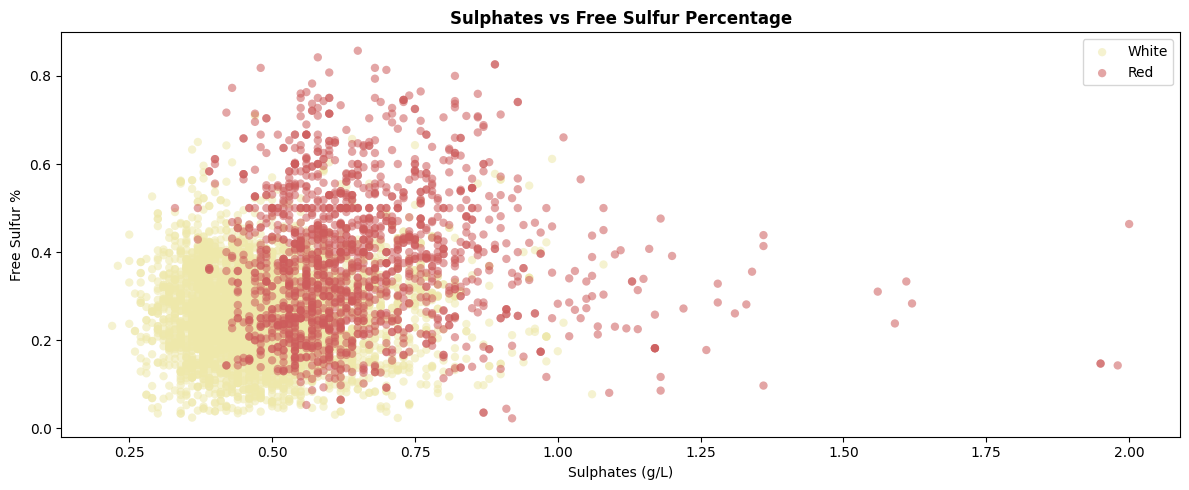

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

# create a single scatter plotting free sulfur % by sulphate amount 
for wine_type in combined['type'].unique():
    data = combined[combined['type'] == wine_type]
    ax.scatter(data["sulphates"], data["free sulfur pct"], 
               alpha=0.55, edgecolor='none',
               color=default_colors[wine_type],
               label=wine_type.title())

ax.set_xlabel('Sulphates (g/L)')
ax.set_ylabel('Free Sulfur %')
ax.set_title('Sulphates vs Free Sulfur Percentage',
            fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('Images/sulphates_vs_so2pct_scatter.png', dpi= 125)   

#### **Question 15 findings:**

Within each type, **no strong relationship is apparent** between sulphates and free sulphur %. This is particularly illustrated by red wines with upper outlier sulphate measurements which do not follow any discernible pattern.

It is possible this shows that although sulphates (potassium metabisulfite) are added by winemakers as a preservative, resulting free sulphur percentage is more significantly impacted by the abundance (or lack of abundance) of binding agents.

## Question 16
#### *Pandas/NumPy*

#### Based on this relationship between sulphates and free sulfur, is there an optimal quantity of added sulphates for preservation?

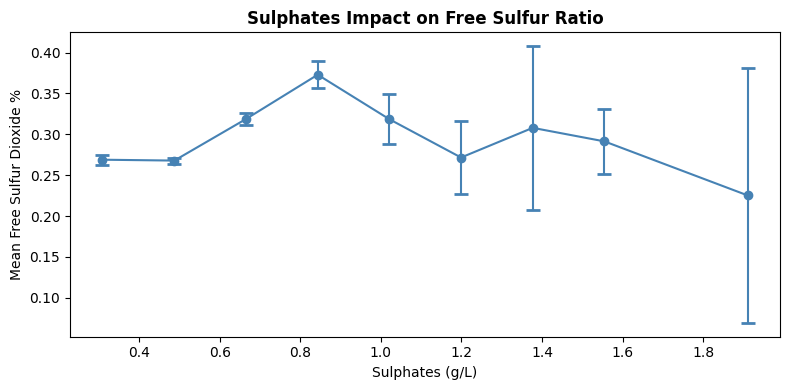

In [27]:
# bin sulphates into 10 intervals
sulphate_bins = pd.cut(combined['sulphates'], bins=10)

# aggregate free sulfur pct statistics for each bin
binned = combined.groupby(sulphate_bins)['free sulfur pct'].agg(['mean', 'std', 'count'])

# calculate 95% confidence interval margin of error
binned['se'] = binned['std'] / np.sqrt(binned['count'])
binned['moe'] = 1.96 * binned['se']

fig, ax = plt.subplots(figsize=(8, 4))

# use bin midpoints for x-axis positioning
x = [b.mid for b in binned.index]

ax.errorbar(x, binned['mean'], yerr=binned['moe'], 
            marker='o', capsize=5, capthick=2, color='steelblue')
ax.set_xlabel('Sulphates (g/L)')
ax.set_ylabel('Mean Free Sulfur Dioxide %')
ax.set_title('Sulphates Impact on Free Sulfur Ratio',
            fontweight="bold")
plt.tight_layout()
plt.savefig('Images/sulphates_vs_sulfur_err.png', dpi= 125)   

#### **Question 16 findings:**

There is a **weak positive trend up to ~0.85 g/L** of sulphates (added). However, that level the relationship breaks down-means fluctuate and error bars widen dramatically. This could be due to small samples sizes at high sulphate levels, making those estimates unreliable

Overall, modest positive association in the typical range (0.3-0.8 g/L), but **adding more sulphates doesn't appear to linearly increase free sulfur availability indefinitely.** It's possible at higher concentrations there is increased binding with other compounds. Similarly, free sulfur percentage could be impacted by markers such as pH, or non-captured features like age. In either case, it doesn't seem like sulphate quantity alone guarantees proportionally increased antioxidant/antimicrobial protection. 

## Question 17
#### *Function*

#### How many outliers are there for each chemical marker (3xMAD from Mean)?

In [28]:
def calculate_mad(ser):
    '''
    Calculate Mean Absolute Deviation.
    '''
    return np.mean(np.abs(ser - np.mean(ser)))

In [29]:
numerical_markers = combined.select_dtypes(include='number').columns.drop('quality')

# build MAD-based outlier detection summary for each feature
mad = pd.DataFrame(index=numerical_markers)

mad['MAD'] = combined[numerical_markers].agg(calculate_mad)
mad['mean'] = combined[numerical_markers].mean()

# lower threshold: 3 MADs below mean, floored at 0 for non-negative features
mad['lower thresh'] = (mad['mean'] - 3 * mad['MAD']).clip(lower=0)
mad['n below'] = [(combined[col] < mad.loc[col, 'lower thresh']).sum() for col in numerical_markers]

# upper threshold: 3 MADs above mean
mad['upper thresh'] = mad['mean'] + 3 * mad['MAD']
mad['n above'] = [(combined[col] > mad.loc[col, 'upper thresh']).sum() for col in numerical_markers]

mad

,MAD,mean,lower thresh,n below,upper thresh,n above
fixed acidity,0.914425,7.215307,4.472033,7,9.958581,286
volatile acidity,0.124388,0.339666,0.000000,0,0.712829,229
acidity ratio,8.337807,25.338136,0.324716,0,50.351557,153
citric acid,0.105833,0.318633,0.001135,151,0.636131,190
residual sugar,3.902331,5.443235,0.000000,0,17.150227,154
chlorides,0.020647,0.056034,0.000000,0,0.117974,210
free sulfur dioxide,14.019184,30.525319,0.000000,0,72.582872,96
total sulfur dioxide,45.679511,115.744574,0.000000,0,252.783109,20
free sulfur pct,0.094823,0.286768,0.002298,0,0.571238,219
density,0.002483,0.994697,0.987246,3,1.002147,20


#### **Question 17 findings:**

Notable upper outlier counts (These features have heavy right-skewed distributions): 
1. Fixed acidity - 286
2. Volatile acidity - 229
3. Chlorides 210
4. Free sulfur pct - 219

Note: Depending on modeling object, may want to consider log transforms (compress right skew) or robust methods for modeling to reduce outlier impact.

Notable lower outlier counts: 
1. Citric acid - 151
2. pH - 15
3. Fixed Acidity - 7
4. Density - 3

Cleanest features: 
1. Total sulfur dioxide - 20 above / 0 below
2. Density - 20 above / 3 below


## Question 18
#### *Pandas/Numpy*

#### Do any outlier groupings appear to have a significant impact on quality?

In [30]:
# initialize dataframes to track outlier quality by wine type and direction
# goal: determine if outliers in each feature tend to be higher or lower quality wines
red_low = pd.DataFrame(index=mad.index)
red_high = pd.DataFrame(index=mad.index)
white_low = pd.DataFrame(index=mad.index)
white_high = pd.DataFrame(index=mad.index)

for wine_type in combined['type'].unique():
    type_subset = combined[combined['type'] == wine_type]
    # get quality mean and std by type 
    type_mean = type_subset['quality'].mean()
    type_std = type_subset['quality'].std()
    
    # select appropriate dataframes based on wine type
    low_df = red_low if wine_type == 'red' else white_low
    high_df = red_high if wine_type == 'red' else white_high
    
    for column in mad.index:
        lower_thresh = mad.loc[column, 'lower thresh']
        upper_thresh = mad.loc[column, 'upper thresh']
        
        # identify wines with outlier values for this feature
        low_fliers = type_subset[type_subset[column] <= lower_thresh]['quality']
        high_fliers = type_subset[type_subset[column] >= upper_thresh]['quality']
        
        # compare quality of low-end outliers to wine type average
        low_df.loc[column, 'n'] = len(low_fliers)
        low_df.loc[column, 'type quality'] = type_mean
        low_df.loc[column, 'outlier quality'] = low_fliers.mean() if len(low_fliers) > 0 else np.nan
        low_df.loc[column, 'outlier z-score'] = (low_fliers.mean() - type_mean) / type_std if len(low_fliers) > 0 else np.nan
        
        # compare quality of high-end outliers to type average
        high_df.loc[column, 'n'] = len(high_fliers)
        high_df.loc[column, 'type quality'] = type_mean
        high_df.loc[column, 'outlier quality'] = high_fliers.mean() if len(high_fliers) > 0 else np.nan
        high_df.loc[column, 'outlier z-score'] = (high_fliers.mean() - type_mean) / type_std if len(high_fliers) > 0 else np.nan

# pack all dataframes for batch processing
dfs = {'red low outliers': red_low, 'red high outliers': red_high, 
       'white low outliers': white_low, 'white high outliers': white_high}

# clean and sort by quality deviation
# positive outlier z-score = outliers are better quality than average
# negative outlier z-score = outliers are worse quality than average
for name, df in dfs.items():
    df = df.dropna()
    df['n'] = df['n'].astype(int)
    dfs[name] = df.sort_values('outlier z-score', ascending=False)

for name, df in dfs.items():
    print(f'\n{name.upper()} - MEAN QUALITY ANALYSIS:\n')
    print(df)
    print('='*75)


RED LOW OUTLIERS - MEAN QUALITY ANALYSIS:

               n  type quality  outlier quality  outlier z-score
citric acid  132      5.636023         5.409091        -0.281006
pH             1      5.636023         4.000000        -2.025860

RED HIGH OUTLIERS - MEAN QUALITY ANALYSIS:

                        n  type quality  outlier quality  outlier z-score
total sulfur dioxide    2      5.636023         7.000000         1.688991
alcohol                14      5.636023         6.571429         1.158298
acidity ratio          12      5.636023         6.333333         0.863469
citric acid            65      5.636023         6.015385         0.469758
fixed acidity         276      5.636023         5.905797         0.334057
free sulfur pct       203      5.636023         5.876847         0.298209
sulphates             150      5.636023         5.853333         0.269092
density                13      5.636023         5.692308         0.069697
pH                     48      5.636023         5.

### **Question 18 findings:**

*Red wines*

- High volatile acidity is a **moderate quality penalty** — likely indicating spoilage or poor fermentation control
- High alcohol and acidity ratio outliers show the **strongest positive signals** with reliable sample size — reinforces alcohol as a ripeness/quality proxy
- Low citric acid is a **minor penalty** while high citric acid is a **moderate positive** signal — demonstrates how citric acid contributes freshness

*White wines*

- High volatile acidity is a **severe quality penalty** — whites are more sensitive to volatile acidity faults
- High total SO₂ and fixed acidity outliers also had **significant quality penalities** — suggests over-processing or imbalanced acidity
- High alcohol and sulphates are **strong positive signals** though less magnitude compared to red wines


*Both types*

High chlorides was a **moderate signal of lower quality** across both types — excess salinity is universally undesirable

**These results show some promise for the potential of classifying quality outliers from physicochemical markers. However, the z-score deviations in quality are still relatively small.**


## Question 19
#### *Pandas/Numpy*

#### Which quality rating is most consistent in terms of chemical composition?

In [31]:
numerical_columns = combined.select_dtypes(include='number').columns.drop('quality')

for wine_type in combined['type'].unique():
    data = combined[combined['type'] == wine_type]
    
    # z-score normalize features so variance is comparable across different scales
    data_arr = data[numerical_columns].to_numpy()
    means = np.mean(data_arr, axis=0)
    stds = np.std(data_arr, axis=0)
    normalized_arr = (data_arr - means) / stds

    # append quality prior to grouping
    normalized = pd.DataFrame(normalized_arr, columns=numerical_columns)
    normalized['quality'] = data['quality'].values
    
    # calculate variance of each feature within each quality level
    # then average across features to get overall "consistency" per quality tier
    variance_by_quality = normalized.groupby('quality')[numerical_columns].var()
    mean_variance = variance_by_quality.mean(axis=1)
    
    # low variance = wines at that quality level have similar chemical profiles
    # high variance = wines at that quality level are chemically diverse
    print(f"\n{wine_type.title()} Wine:")
    print(f"  Most consistent: quality {mean_variance.idxmin()} (var: {mean_variance.min():.4f})")
    print(f"  Least consistent: quality {mean_variance.idxmax()} (var: {mean_variance.max():.4f})")


White Wine:
  Most consistent: quality 9 (var: 0.6333)
  Least consistent: quality 3 (var: 3.4949)

Red Wine:
  Most consistent: quality 5 (var: 0.8962)
  Least consistent: quality 4 (var: 1.1852)


### **Question 19 findings:**

*See print above*

Results indicate that its likely **good white wine can more accurately classified** than bad white wine. *Similarly*, **bad red wine is probably hard to classify**, but it is unclear if good red wine has consistent features.

## Question 20
#### *Function*

#### Does high quality wine mean more calories?

In [32]:
def estimate_calories(alcohol, sugar, serving_ml=150):
    """
    Estimates wine calories per serving using alcohol and residual 
    sugar content.Assumes alcohol has 7 calories per gram and that 
    sugar has 4 calories per gram. Calorie/gram measurements are 
    approximations.
    
    Parameters:
        alcohol (float) - Alcohol by volume (%)
        sugar (float) - Residual sugar (g/L)
        serving_ml (int) - Serving size in milliliters 
                           (default to 150ml standard pour)
    
    Returns:
        calorie_count (float) - Estimated calories per serving (float)
    """
    # alcohol has a density by volume of liquid
    ALHOHOL_DENSITY = 0.789
    # alcohol calorie total calculated by first converting ABV% to grams
    grams_alc = (alcohol / 100) * serving_ml * ALHOHOL_DENSITY
    alc_cals = grams_alc * 7
    # sugar calorie total calculated (convert ml --> L)
    sugar_grams = sugar * (serving_ml / 1000)
    sugar_cals = sugar_grams * 4

    calorie_count = round(alc_cals + sugar_cals, 1)
    
    return calorie_count

# add calories to combined df with function just defined
combined['estimated calories'] = list(map(estimate_calories, 
                                     combined['alcohol'], 
                                     combined['residual sugar']))

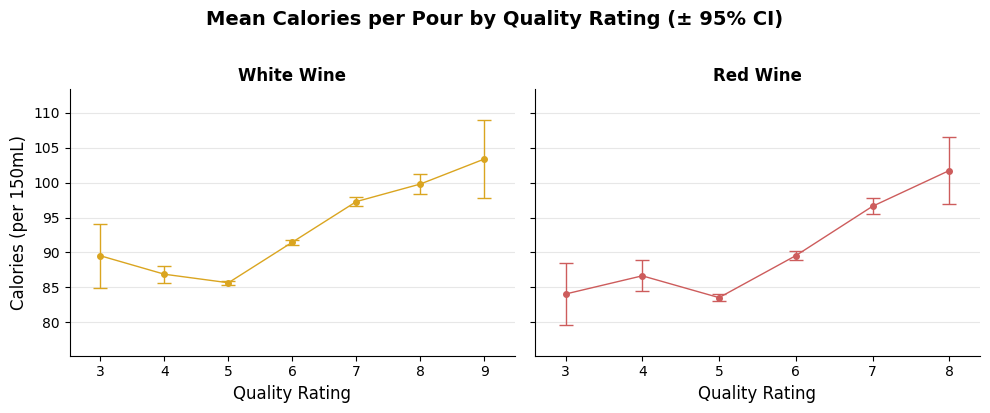

In [33]:
# group by type and quality, get stats for confidence interval
cal_stats = (combined.groupby(["type", "quality"])["estimated calories"]
             .agg(["mean", "std", "count"]))

# 95% CI margin of error: z * std / sqrt(n)
cal_stats['moe'] = 1.96 * cal_stats['std'] / np.sqrt(cal_stats['count'])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

for ax, wine_type in zip(axes, combined["type"].unique()):
    # slice multiindex to get just this wine type
    data = cal_stats.loc[wine_type]
    
    # plot as error bar chart
    ax.errorbar(data.index, 
                data["mean"],
                yerr=data['moe'],
                marker='o',
                markersize=4,
                capsize=5, 
                capthick=1,
                linewidth=1,
                color='indianred' if wine_type == 'red' else 'goldenrod')
    
    ax.set_xlabel("Quality Rating", fontsize=12)
    # only label y-axis on left plot since sharey=True
    ax.set_ylabel("Calories (per 150mL)" if wine_type == 'white' else "", 
                  fontsize=12)
    ax.set_title(f'{wine_type.title()} Wine', 
                 fontweight='bold', 
                 fontsize=12)
    ax.set_xticks(data.index)
    # breathing room around data points
    ax.margins(x=0.08, y=0.15)
    ax.grid(axis='y', alpha=0.3)
    # cleaner look without top/right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Mean Calories per Pour by Quality Rating (± 95% CI)",
             fontsize=14,
             fontweight="bold",
             y=1.02)
plt.tight_layout()
plt.savefig('Images/quality_vs_calories.png', dpi= 125)   

### **Question 20 findings:**

Both red and white showing a **clear upward trend relating calorie content to quality**. 

This pattern bears strong resemblance the the relationship between alcohol and quality (which makes sense given alcohol is a key part of the calculation). However, this feature tells a different story to the end consumer (better flavor = less healthy).

## Question 21
#### *Exciting - Machine Learning*

#### How well do physciochemical markers work for predicting wine type (with Logistic Regression)?

In [34]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve, balanced_accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.manifold import Isomap
from matplotlib.colors import ListedColormap

In [35]:
# extract label/orginal values from feature set (original and w/ feature engineering)
unchanged_type_features = original_combined.drop(['quality','type'], axis=1)

# transform type and assign it as binary label (red=1, white=0)
y = (combined['type'] == 'red').astype(int)

# instantiate model with hyperparameters
model = LogisticRegression(max_iter=1000)

# split into training and testing sets (use stratify so each set contains same % of samples of each type as the complete set)
X_train, X_test, y_train, y_test = train_test_split(unchanged_type_features, y, test_size=0.2, random_state=42, stratify=y)

# fit model to training data
model.fit(X_train, y_train)

# predict on new data
y_pred = model.predict(X_test)

In [36]:
# evaluate accuracy (false postive, false negative, and balanced f1)
print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred))

accuracy: 0.988
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.96      0.97       320

    accuracy                           0.99      1300
   macro avg       0.99      0.98      0.98      1300
weighted avg       0.99      0.99      0.99      1300



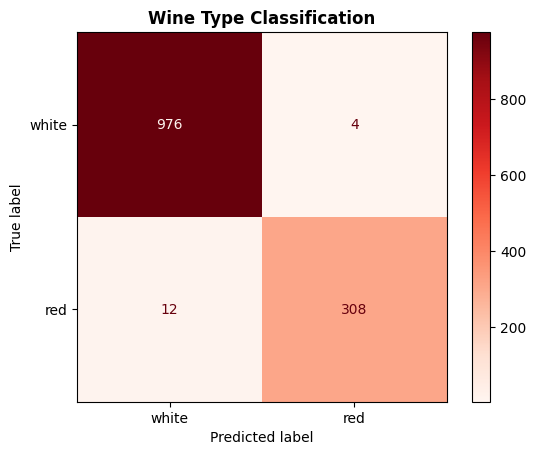

In [37]:
# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['white', 'red'], cmap='Reds')
plt.title('Wine Type Classification', fontweight='bold')
plt.savefig('Images/lr_confusion.png', dpi= 125)   

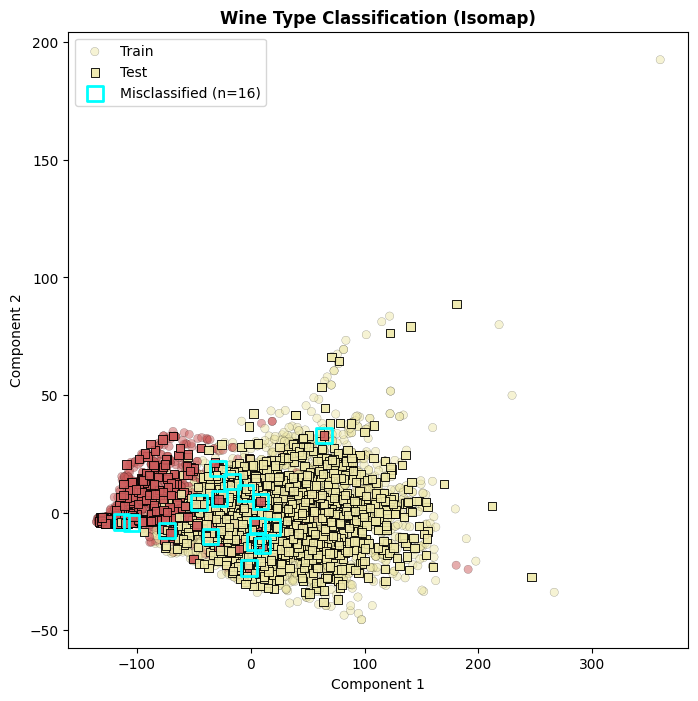

In [38]:
# create isomap to show feature distances in low dimensional space
# reduce dimensions from 11 to 2 using isomap (preserves geodesic distances)
iso = Isomap(n_components=2, n_neighbors=10)  # n_neighbors=10 to resolve error
X_train_projected = iso.fit_transform(X_train)
X_test_projected = iso.transform(X_test)

y_pred = model.predict(X_test)
# find indices where prediction != true label
wrong_idx = np.where(y_pred != y_test)[0] 

plt.figure(figsize=(8, 8))

# training points as background context (plot two components)
plt.scatter(X_train_projected[:, 0], X_train_projected[:, 1], 
            c=y_train, 
            edgecolor='black',
            linewidth=0.2,
            alpha=0.5,  # low opacity to show density
            cmap=ListedColormap(['palegoldenrod', 'indianred']),
            label='Train')

# test points stand out from training data
plt.scatter(X_test_projected[:, 0], X_test_projected[:, 1], 
            c=y_test,  # colored by true label
            edgecolor='black',
            linewidth=0.7,
            alpha=0.9,  # high opacity
            marker='s',  # squares to distinguish from train
            cmap=ListedColormap(['palegoldenrod', 'indianred']),
            label='Test')

# overlay cyan outline on misclassified points
plt.scatter(X_test_projected[wrong_idx, 0], X_test_projected[wrong_idx, 1],
            c='none',  # transparent fill shows true class color beneath
            edgecolor='cyan',
            linewidth=2,
            s=125,  # larger marker for visibility
            marker='s',
            label=f'Misclassified (n={len(wrong_idx)})')

plt.legend()
plt.title('Wine Type Classification (Isomap)', fontweight='bold')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.savefig('Images/lr_iso.png', dpi= 125)   

### **Question 21 findings:**

Logistic regression appears to be a **very reliable method for classifying wines by type** using only physicochemical properties.

The basic model has a very low false positive rate (1% aka 99% precision) and almost an equally low false negative rate (2% aka 98% recall) across both types of wine. The model does appear to **perform better for white wine classifcation** than red wine classification (with only 4/980 white wines in the test set being miss-labeled). 

Furthermore, the Isomap is a captivating visual which shows how the 11 chemical features used in the model can be projected to 2 dimensions with **clear, minimally overlapping clusters.** The map clealry illustrates how chemical profiles are fundamentally different between types. Moreover, it validates that the 16 misclassified points almost all fall within the boundary region where the clusters meet. So, the model is evidently only prone to errors when wines have ambiguous chemical signatures.



## Question 22
#### *Exciting - Machine Learning*

#### Can we improve performance through feature engineering?

In [39]:
# extract labels from engineered feature set (original and w/ feature engineering)
enhanced_type_features = combined.drop(['quality','type'], axis=1)

*Create some functions to assist, as necessary, with repeatable/configurable feature engineering techniques*

In [40]:
def one_hot_encode_features(df, feature_list=None):
    '''
    encode_features one-hot encodes categorical columns.
    Parameters:
        df (DataFrame) - dataframe with categorical columns to encode
        feature_list (list or None) - columns to encode; if None, encodes all object/category columns
    Returns:
        df with specified columns one-hot encoded
    '''
    # if no features specified, encode all categorical columns
    if feature_list is None:
        feature_list = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # one-hot encode specified columns
    return pd.get_dummies(df, columns=feature_list, dtype=int)

In [41]:
def reduce_multicollinearity(df, threshold, exception_list=None, printout=True):
    '''
    reduce_multicollinearity removes highly correlated features from a dataframe.
    First of each correlated pair is kept unless in exception list.
    Parameters:
        df (DataFrame) - dataframe with numeric columns to evaluate
        threshold (float) - correlation threshold above which to drop columns (e.g., 0.8)
        exception_list (list or None) - columns to keep regardless of correlation
    Returns:
        df with highly correlated columns removed, non-numeric columns preserved
    '''
    # handle default exception list
    if exception_list is None:
        exception_list = []
    # select float columns for correlation check
    float_cols = df.select_dtypes(include='float').columns
    # build absolute correlation matrix
    corr_matrix = df[float_cols].corr().abs()
    # extract upper triangle (excludes diagonal and duplicate pairs)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # identify columns exceeding threshold, respecting exceptions
    drop_features = [column for column in upper.columns 
                     if any(upper[column] > threshold) 
                     and column not in exception_list]
    # print correlation pairs that triggered drops
    if drop_features and printout:
        print(f'dropped: {drop_features}')
    # drop correlated columns from original df, preserving all other columns
    return df.drop(columns=drop_features)

In [42]:
# create reusable scaling (transformation) functions
def min_max_scaling(df):
    '''
    min_max_scaling scales float columns to a 0-1 range.
    Parameters:
        df (DataFrame) - dataframe with columns to scale
    Returns:
        df with scaled columns
    '''
    # select float columns only
    features_to_scale = df.select_dtypes(include='float').columns
    scaler = MinMaxScaler()
    # scale each column individually
    for column in features_to_scale:
        df[column] = scaler.fit_transform(df[[column]])
    return df


def apply_yeo_johnson(df, standardize=True):
    '''
    apply_yeo_johnson reduces skewness in numeric float columns using
    the yeo-johnson power transformation. Handles zero and negative values.
    Parameters:
        df (DataFrame) - dataframe with columns to transform
        standardize (bool) - if True, also applies z-standardization after transform
    Returns:
        df with transformed columns
    '''
    # select float columns only
    features_to_scale = df.select_dtypes(include='float').columns
    transformer = PowerTransformer(method='yeo-johnson', standardize=standardize)
    # transform each column individually
    for column in features_to_scale:
        df[column] = transformer.fit_transform(df[[column]])
    return df

In [43]:
def flexible_binning(df, column_to_bin, bins='auto', labels=None, new_column=None):
    '''
    Flexible_binning transforms a continuous column into categorical bins.
    Parameters:
        df (DataFrame) - dataframe onto which binned column will be appended
        column_to_bin (string) - name of existing column to bin
        bins (int, list, or 'auto') - number of equal-width bins, list of bin edges, or 'auto' for quantile-based
        labels (list or None) - labels for bins; if None, uses interval notation
        new_column (string or None) - name for new column; if None, uses col + '_binned'
    Returns:
        df with new binned column
    '''
    # set default new column name
    if new_column is None:
        new_column = f'{column_to_bin}_binned'
    
    # determine binning method
    if bins == 'auto':
        # quartile-based binning
        df[new_column] = pd.qcut(df[column_to_bin], q=4, labels=labels, duplicates='drop')
    elif isinstance(bins, int):
        # equal-width binning with n bins
        df[new_column] = pd.cut(df[column_to_bin], bins=bins, labels=labels)
    elif isinstance(bins, list):
        # custom bin edges
        df[new_column] = pd.cut(df[column_to_bin], bins=bins, labels=labels)
    return df

*Apply selected feature engineering methods*

In [44]:
# transform skewed features + z_standardize
enhanced_type_features = apply_yeo_johnson(enhanced_type_features, standardize=True)

# encode categorical columns last
enhanced_type_features = one_hot_encode_features(enhanced_type_features)

# drop colinear (>0.8); make an exception for acidity ratio
enhanced_type_features = reduce_multicollinearity(enhanced_type_features, 0.75)

dropped: ['acidity ratio', 'total sulfur dioxide', 'estimated calories']


In [45]:
# instantiate model with hyperparameters
model = LogisticRegression(max_iter=1000)

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(enhanced_type_features, y, test_size=0.2, random_state=42, stratify=y)

# fit model to training data
model.fit(X_train, y_train)

# Predict on new data
y_pred = model.predict(X_test)

In [46]:
# evaluate
print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred))

accuracy: 0.992
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.98      0.99      0.98       320

    accuracy                           0.99      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       0.99      0.99      0.99      1300



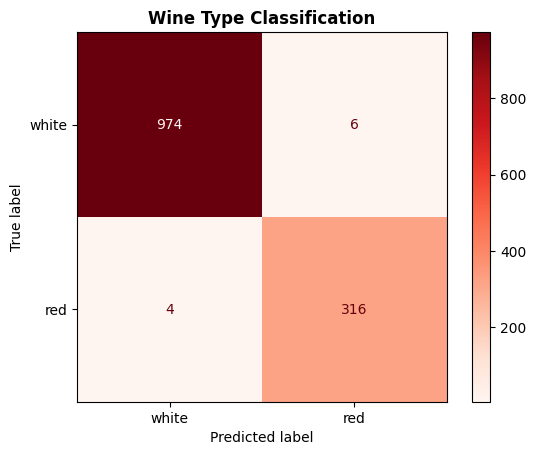

In [47]:
# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['white', 'red'], cmap='Reds')
plt.title('Wine Type Classification', fontweight='bold')
plt.savefig('Images/lr_confusion_with_engineering.png', dpi= 125)   

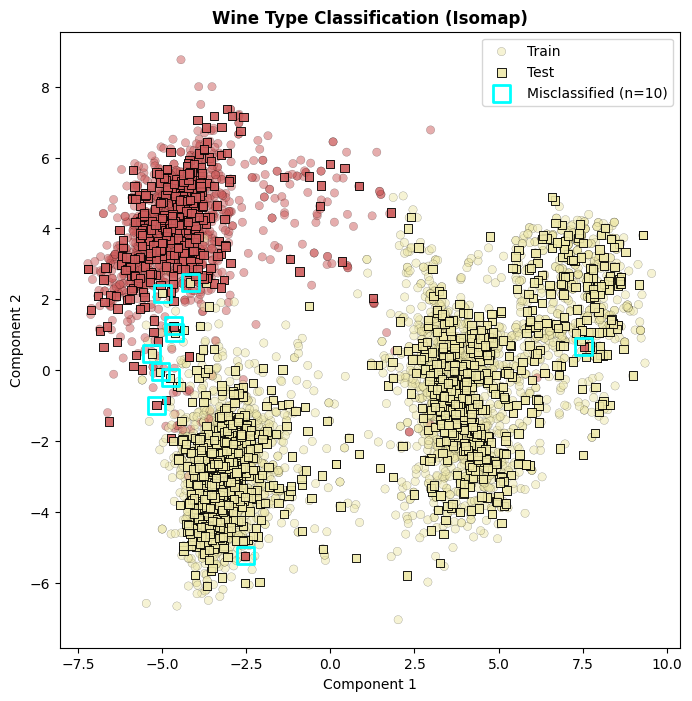

In [48]:
# reduce dimensions from 11 features to 2 for visualization
# n_neighbors increased to avoid disconnected graph warning
iso = Isomap(n_components=2, n_neighbors=10)
# fit on training data, transform both train and test
X_train_projected = iso.fit_transform(X_train)
X_test_projected = iso.transform(X_test)

# predict on test set
y_pred = model.predict(X_test)
# find misclassified indices
wrong_idx = np.where(y_pred != y_test)[0]

# create figure
plt.figure(figsize=(8, 8))

# plot training points as circles with lower opacity
plt.scatter(X_train_projected[:, 0], X_train_projected[:, 1], 
            c=y_train, 
            edgecolor='black',
            linewidth=0.2,
            alpha=0.5,
            cmap=ListedColormap(['palegoldenrod', 'indianred']),
            label='Train')

# plot test points as squares with higher opacity
plt.scatter(X_test_projected[:, 0], X_test_projected[:, 1], 
            c=y_test, 
            edgecolor='black',
            linewidth=0.7,
            alpha=0.9,
            marker='s',
            cmap=ListedColormap(['palegoldenrod', 'indianred']),
            label='Test')

# highlight misclassified points with bright cyan outline
plt.scatter(X_test_projected[wrong_idx, 0], X_test_projected[wrong_idx, 1],
            c='none',
            edgecolor='cyan',
            linewidth=2,
            s=150,
            marker='s',
            label=f'Misclassified (n={len(wrong_idx)})')

# add legend and labels
plt.legend()
plt.title('Wine Type Classification (Isomap)', fontweight='bold')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.savefig('Images/lr_iso_with_engineering.png', dpi= 125)   

### **Question 22 findings:**

The baseline logistic regression model was already a very accurate classifier. However, through feature engineering, model performance was improved.

Notably, **recall for red wines gained 3%**, improving from 0.96 to 0.99. This improvement in recall only **cost <1% (or an additional 2/980 false positives) in precision** for red wines. The scores for white wines were reliatively unchanged due to the larger sample size. 

I found the **Isomap change to be the most striking biproduct of feature engineering.** The boundaries between wine type are far wider than they were previosuly. Also, it was fascinating to see white wines disband into 3 clusters. I expect that these **clusters are representative of sweetness which was added as a one-hot encoded feature.**


## Question 23
#### *Exciting - Machine Learning*

#### Does naive bayes perform as well or similarly to logistic regression for classifying wine type with the plain feature set?

In [49]:
# instantiate model
model = GaussianNB()

X_train, X_test, y_train, y_test = train_test_split(unchanged_type_features, y, test_size=0.2, random_state=42)

# fit model
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

In [50]:
# evaluate
print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred))

accuracy: 0.966
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       978
           1       0.91      0.96      0.93       322

    accuracy                           0.97      1300
   macro avg       0.95      0.96      0.96      1300
weighted avg       0.97      0.97      0.97      1300



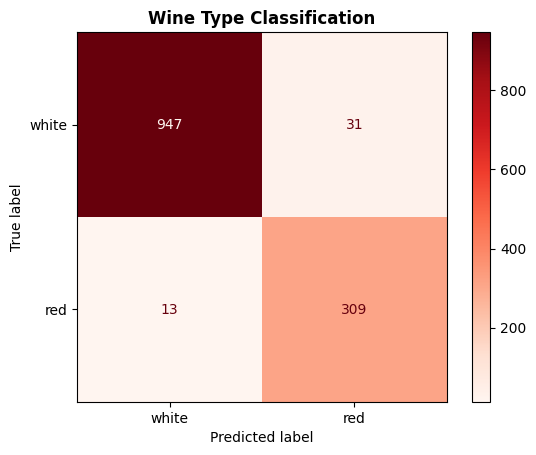

In [51]:
# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['white', 'red'], cmap='Reds')
plt.title('Wine Type Classification', fontweight='bold')
plt.savefig('Images/nb_confusion.png', dpi= 125)   

### **Question 23 findings:**

For is relative computational ease, Naive Bayes performs very well at classifying wines by type with physicochemical features. Most of the missclassifications appear to be white wines which the model labels as red. 

Still, with **overall (avg) precision and recall scores >0.95, the model classifies wines quite reliably**.

## Question 24
#### *Exciting - Machine Learning*

#### What classification model works best for predicting quality outliers (bad or good) using physicochemical features?

In [52]:
# loop through each wine type to build separate classification models
for wine_type in combined['type'].unique():
    type_subset = combined.loc[combined['type'] == wine_type]
    
    # create binary target: 0 = mid quality (5-6), 1 = outlier quality (3-4, 7-10)
    subset_target = type_subset['quality'].apply(lambda x: 0 if x in [5, 6] else 1)
    subset_features = type_subset.select_dtypes(include='number').drop(['quality'], axis=1)
    
    # reset indices to avoid alignment issues after subsetting
    subset_features = subset_features.reset_index(drop=True)
    subset_target = subset_target.reset_index(drop=True)
    
    # stratify ensures train/test have same class proportions
    X_train, X_test, y_train, y_test = train_test_split(
        subset_features, subset_target, test_size=0.20, random_state=42, stratify=subset_target
    )
    
    # define models with hyperparameter grids for tuning (sampled classification models in Sci-Kit documentation)
    # class_weight='balanced' to address class imbalance (fewer outliers than mid)
    # f1 score optimization to avoid rewarding lazy behavior --> exchanging precision for high recall
    models = {
        'logistic': GridSearchCV(
            Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
            ]),
            param_grid={'classifier__C': [0.1, 1, 10]},  # regularization strength
            cv=3,
            scoring='f1',
            n_jobs=-1  # uses all cores to process efficiently
        ),
        'random forest': GridSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            param_grid={
                'n_estimators': [100, 200],  # number of trees
                'max_depth': [5, 10],  # tree depth limit
                'min_samples_leaf': [1, 4]  # minimum samples per leaf
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        ),
        'gradient boosting': GridSearchCV(
            GradientBoostingClassifier(random_state=42),
            param_grid={
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.1, 0.2]  # tree shrinkage
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        ),
        'svm': GridSearchCV(
            Pipeline([
                ('scaler', StandardScaler()),  # svm requires scaled features
                ('classifier', SVC(class_weight='balanced', probability=True, random_state=42))
            ]),
            param_grid={'classifier__C': [1, 10]},
            cv=3,
            scoring='f1',
            n_jobs=-1
        ),
        'adaboost': GridSearchCV(
            AdaBoostClassifier(random_state=42),
            param_grid={
                'n_estimators': [50, 100],
                'learning_rate': [0.1, 0.5, 1.0]  # contribution per weak learner
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        ),
        'knn': GridSearchCV(
            KNeighborsClassifier(),
            param_grid={
                'n_neighbors': [5, 11],  # odd numbers avoid ties
                'weights': ['distance'],  # weight by inverse distance
                'metric': ['euclidean']
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        )
    }
                                   
    print(f'{wine_type.upper()} REPORT\n')
    
    # track best model based on f1 score for outlier class
    best_f1 = 0
    best_model = None
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        
        print(f'{name} best params: {model.best_params_}')
        
        y_pred = model.predict(X_test)
        
        # f1_score default is binary with pos_label=1 (outlier class)
        outlier_f1 = f1_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        
        print(f'\tbalanced accuracy: {bal_acc:.3f}, outlier f1: {outlier_f1:.3f}\n')
        
        # update best model if current f1 is higher
        if outlier_f1 > best_f1:
            best_f1 = outlier_f1
            best_model = name
            best_pred = y_pred
    
    # print full classification report for winning model
    print(f'BEST MODEL: {best_model}')
    print(classification_report(y_test, best_pred, target_names=['mid', 'outlier']))
    print('=' * 75)

WHITE REPORT

logistic best params: {'classifier__C': 10}
	balanced accuracy: 0.692, outlier f1: 0.533

random forest best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
	balanced accuracy: 0.750, outlier f1: 0.630

gradient boosting best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
	balanced accuracy: 0.748, outlier f1: 0.637

svm best params: {'classifier__C': 10}
	balanced accuracy: 0.745, outlier f1: 0.601

adaboost best params: {'learning_rate': 1.0, 'n_estimators': 100}
	balanced accuracy: 0.614, outlier f1: 0.398

knn best params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
	balanced accuracy: 0.719, outlier f1: 0.590

BEST MODEL: gradient boosting
              precision    recall  f1-score   support

         mid       0.86      0.92      0.89       731
     outlier       0.71      0.57      0.64       249

    accuracy                           0.83       980
   macro avg       0.79      0.75      0.76       9

### **Question 24 findings:**

Looping through a model dictionary and leveraging GridSearchCV made assessing the the best baseline model and hyperparamters far more systemartic and efficient than if this optimization was performed manually. 

Ultimately, from the basic hyperparamter grids and represented classification models (pulled from the Sci-Kit user docmentation), it appears that different models work better for quality outlier detection depending on wine type. 

**Gradient Boosting** (with 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200) was the **best model for outlier quality detection when applied to white wines.** Still, Random forest was a close contender.

**Random Forest** (with 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200) was the **best model for outlier quality detection when applied to red wines.** Bearing some resemblance to white wines, gradient boosting was the closest contender (when evaluated with f1 performance). 

I suspect that gradient boosting and random forest outperformed other model types because they are better at modeling non-linear interactions between features. Prior analysis of the wine features had shown that wine quality is heavily subject to nuanced balance between various components. In many instances features could be seen (or suspected) to behave differently depending on interactions with other features (e.g. free sulfur and pH). Such interactions likely aren't captured as well by linear models.

Overall, the outlier detection performance might be viewed as **acceptable depending upon intended application**. The model would probably be okay for flagging potential outliers to further review given stronger precision than recall across both wine types. However, **weak recall scores of 0.57 and 0.64** imply that many outliers would go undetected. 

## Question 25
#### *Exciting - Machine Learning*

#### How much can predictive performance (for detecting outliers) be improved with threshold tuning?

In [53]:
# loop through each wine type to build separate classification models
# predicting quality outliers (scores 3-4, 7-10) vs mid-range (scores 5-6)
for wine_type in combined['type'].unique():
    type_subset = combined.loc[combined['type'] == wine_type]
    
    # create binary target: 0 = mid quality (5-6), 1 = outlier quality (3-4, 7-10)
    subset_target = type_subset['quality'].apply(lambda x: 0 if x in [5, 6] else 1)
    subset_features = type_subset.select_dtypes(include='number').drop(['quality'], axis=1)
    
    # reset indices to avoid alignment issues after subsetting
    subset_features = subset_features.reset_index(drop=True)
    subset_target = subset_target.reset_index(drop=True)
    
    X_train, X_test, y_train, y_test = train_test_split(
        subset_features, subset_target, test_size=0.20, random_state=42, stratify=subset_target
    )
    
    # define models with hyperparameter grids
    # class_weight='balanced' addresses class imbalance, scoring='f1' optimizes for outlier detection
    models = {
        'random forest': GridSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            param_grid={
                'n_estimators': [100, 200],
                'max_depth': [5, 10],
                'min_samples_leaf': [1, 4]
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        ),
        'gradient boosting': GridSearchCV(
            GradientBoostingClassifier(random_state=42),
            param_grid={
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.1, 0.2]
            },
            cv=3,
            scoring='f1',
            n_jobs=-1
        )
    }
                                   
    print(f'{wine_type.upper()} REPORT\n')
    
    # track best model based on f1 score for outlier class
    best_f1 = 0
    best_model = None
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        
        print(f'{name} best params: {model.best_params_}')
        
        # default threshold: classify as outlier if P(outlier) >= 0.5
        y_pred_default = model.predict(X_test)
        f1_default = f1_score(y_test, y_pred_default)
        bal_acc_default = balanced_accuracy_score(y_test, y_pred_default)
        
        # get predicted probabilities for outlier class (mid=0, outlier=1)
        y_proba = model.predict_proba(X_test)[:, 1]

        # precision_recall_curve returns precision/recall at each unique probability threshold
        # lowering threshold increases recall (catch more outliers) but decreases precision (more false positives)
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
        
        # compute f1 at each threshold to find optimal precision-recall tradeoff
        # 1e-10 avoids division by zero when precision + recall = 0
        # precisions/recalls have one extra element (see documentation); slice [:-1] to match thresholds length 
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        
        # select threshold that maximizes f1
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        
        # apply tuned threshold: classify as outlier if P(outlier) >= best_threshold
        y_pred_tuned = (y_proba >= best_threshold).astype(int)
        f1_tuned = f1_scores[best_idx]
        bal_acc_tuned = balanced_accuracy_score(y_test, y_pred_tuned)
        
        f1_delta = f1_tuned - f1_default
        
        print(f'\tdefault (0.5):    bal_acc: {bal_acc_default:.3f}, f1: {f1_default:.3f}')
        print(f'\ttuned ({best_threshold:.3f}):   bal_acc: {bal_acc_tuned:.3f}, f1: {f1_tuned:.3f} ({f1_delta:+.3f})\n')
        
        # update best model if tuned f1 is higher
        if f1_tuned > best_f1:
            best_f1 = f1_tuned
            best_model = name
            best_pred = y_pred_tuned
    
    # print full classification report for winning model
    print(f'BEST MODEL: {best_model}')
    print(classification_report(y_test, best_pred, target_names=['mid', 'outlier']))
    print('=' * 75)

WHITE REPORT

random forest best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
	default (0.5):    bal_acc: 0.750, f1: 0.630
	tuned (0.404):   bal_acc: 0.776, f1: 0.644 (+0.014)

gradient boosting best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
	default (0.5):    bal_acc: 0.748, f1: 0.637
	tuned (0.437):   bal_acc: 0.764, f1: 0.658 (+0.021)

BEST MODEL: gradient boosting
              precision    recall  f1-score   support

         mid       0.87      0.91      0.89       731
     outlier       0.71      0.61      0.66       249

    accuracy                           0.84       980
   macro avg       0.79      0.76      0.78       980
weighted avg       0.83      0.84      0.83       980

RED REPORT

random forest best params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
	default (0.5):    bal_acc: 0.795, f1: 0.679
	tuned (0.520):   bal_acc: 0.790, f1: 0.680 (+0.000)

gradient boosting best params: {'learning_rate': 0.

### **Question 25 findings:**

Before deciding to pursue threshold tuning, I made an exhaustive effort to improve performance of quality outlier classification through feature engineering. I was relatively unsuccessful and often my attempts at feature engineering produced undesireable effects on accuracy comapred to the baseline. 

Threshold tuning is a somewhat subjective task. By default conditional probability thresholds are set to 0.5 for classification in sci-kit. Depending on the objective, thresholds may be adjusted to reduce false negatives (e.g. cancer detection - better safe than sorry even if more false positives are generated) or conversely to reduce false positives (e.g. filtering spam - maybe its okay if a couple of authentic emails accidently get caught in spam). In the case of wine, I just opted to see if I could improve f1 score (balance of precision and recall). 

Through threshold tuning, outlier detection performance was improved modestly for both white and red wines. Interestingly, tuning thresholds actually caused the **optimal model for red wines to change from random forest to gradient boosting.** Also, while the improvements of +0.014 and +0.044 (whites and reds , respectively), seem marginal, they were both meaningful in comparison to my attempts to improve dectection performance through feature engineering. 

Still, even with threshold tuning, the model faces the **same limitation as before.** For reds, which have better recall than whites, **approx. 1 in 3 wines would continue to be mistakenly be labelled a quality outlier.**